# Phase 1 — Data Integration and Feature Engineering

This notebook rebuilds the Puerto Rico municipal panel using the **master profile as the backbone** and integrates the raw source files you identified as authoritative:

- `data/crime/PR_Crime_Summary_2010_2025.xlsx`
- `data/household_income/municipios_acs_s1901_median_income_2010_2023.csv`
- `data/employment/municipios_acs_s2301_2010_2023.csv`
- `data/employment_establishments/puerto_rico_business_deep_dive_2010_2022.csv`
- `data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv`
- `data/natural_disasters/puerto_rico_earthquakes.json`
- `data/overall_population_info/death_birth_rates/pr_islandwide_vital_rates.csv`

This version also makes the SVI workflow explicit:

1. Build the **15 social vulnerability indicators** from `puerto_rico_master_profile.csv`
2. Create a **standardized additive composite** (`svi_composite_z15`)
3. Create a **PCA-based first component** (`svi_pca_1`)
4. Keep a rebuild-compatible baseline feature:
   - `baseline_vulnerability_index` → set equal to the PCA-based baseline for downstream continuity
5. Export a richer panel for Phase 2 modeling and comparison


In [1]:

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

warnings.filterwarnings("ignore")

BASE_DIR = Path().resolve()
PHASE1_DIR = BASE_DIR / "Phase1"
PHASE1_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = PHASE1_DIR / "figures"
TABLE_DIR = PHASE1_DIR / "tables"
DATA_DIR = PHASE1_DIR / "data"
META_DIR = PHASE1_DIR / "metadata"

for folder in [PHASE1_DIR, FIG_DIR, TABLE_DIR, DATA_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", BASE_DIR)
print("Phase 1 output directory:", PHASE1_DIR)
print("Figures directory:", FIG_DIR)
print("Tables directory:", TABLE_DIR)
print("Data directory:", DATA_DIR)
print("Metadata directory:", META_DIR)

def save_csv(df, filename, index=False, folder=DATA_DIR):
    path = folder / filename
    df.to_csv(path, index=index)
    print(f"Saved: {path}")
    return path

def save_json(obj, filename, folder=META_DIR):
    path = folder / filename
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    print(f"Saved: {path}")
    return path

def save_text(text, filename, folder=META_DIR):
    path = folder / filename
    with open(path, "w") as f:
        f.write(text)
    print(f"Saved: {path}")
    return path

def save_plot(fig, filename, folder=FIG_DIR, dpi=180):
    path = folder / filename
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved figure: {path}")
    return path

def resolve_first_existing(*candidates):
    for candidate in candidates:
        p = Path(candidate)
        if p.exists():
            return p
    raise FileNotFoundError(f"None of the candidate paths exist: {candidates}")

def standardize_municipio(s):
    s = str(s).strip()
    s = s.replace(" Municipio", "").replace(" municipality", "")
    return s.strip()

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

def winsorize_by_train_bounds(df, col, train_mask, q_low=0.01, q_high=0.99):
    train_values = df.loc[train_mask, col].dropna()
    if len(train_values) == 0:
        return None, None, pd.Series(np.nan, index=df.index)
    lo = train_values.quantile(q_low)
    hi = train_values.quantile(q_high)
    return lo, hi, df[col].clip(lower=lo, upper=hi)


Notebook directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy
Phase 1 output directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1
Figures directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures
Tables directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables
Data directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/data
Metadata directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/metadata


## 1. Load master panel and municipality centroids

In [2]:

master_path = resolve_first_existing(
    "../data/puerto_rico_master_profile.csv",
    "data/puerto_rico_master_profile.csv"
)

df = pd.read_csv(master_path)
df.columns = df.columns.str.lower().str.strip()

df["municipio"] = df["municipio"].map(standardize_municipio)
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["municipio", "year"]).copy()
df["year"] = df["year"].astype(int)

if "geoid" in df.columns:
    df["geoid"] = pd.to_numeric(df["geoid"], errors="coerce").astype("Int64")

municipio_coords = {
    'Adjuntas': (18.1627, -66.7222), 'Aguada': (18.3605, -67.1882), 'Aguadilla': (18.4275, -67.1541),
    'Aguas Buenas': (18.2572, -66.1031), 'Aibonito': (18.1408, -66.2663), 'Añasco': (18.2827, -67.1399),
    'Arecibo': (18.4724, -66.7157), 'Arroyo': (17.9658, -66.0614), 'Barceloneta': (18.4505, -66.5385),
    'Barranquitas': (18.1861, -66.3061), 'Bayamón': (18.3808, -66.1557), 'Cabo Rojo': (18.0866, -67.1457),
    'Caguas': (18.2325, -66.0391), 'Camuy': (18.4838, -66.8450), 'Canóvanas': (18.3791, -65.9011),
    'Carolina': (18.3808, -65.9574), 'Cataño': (18.4388, -66.1182), 'Cayey': (18.1119, -66.1663),
    'Ceiba': (18.2633, -65.6474), 'Ciales': (18.3361, -66.4688), 'Cidra': (18.1758, -66.1617),
    'Coamo': (18.0855, -66.3579), 'Comerío': (18.2183, -66.2257), 'Corozal': (18.3411, -66.3161),
    'Culebra': (18.3030, -65.3010), 'Dorado': (18.4588, -66.2677), 'Fajardo': (18.3258, -65.6524),
    'Florida': (18.3625, -66.5614), 'Guánica': (17.9716, -66.9080), 'Guayama': (17.9741, -66.1100),
    'Guayanilla': (18.0130, -66.7919), 'Guaynabo': (18.3580, -66.1111), 'Gurabo': (18.2544, -65.9728),
    'Hatillo': (18.4863, -66.8250), 'Hormigueros': (18.1397, -67.1274), 'Humacao': (18.1497, -65.8274),
    'Isabela': (18.5011, -67.0247), 'Jayuya': (18.2186, -66.5916), 'Juana Díaz': (18.0525, -66.5064),
    'Juncos': (18.2275, -65.9211), 'Lajas': (18.0497, -67.0594), 'Lares': (18.2947, -66.8771),
    'Las Marías': (18.2514, -66.9922), 'Las Piedras': (18.1827, -65.8661), 'Loíza': (18.4330, -65.8797),
    'Luquillo': (18.3725, -65.7166), 'Manatí': (18.4274, -66.4922), 'Maricao': (18.1808, -66.9799),
    'Maunabo': (18.0072, -65.8994), 'Mayagüez': (18.2011, -67.1397), 'Moca': (18.3947, -67.1131),
    'Morovis': (18.3258, -66.4053), 'Naguabo': (18.2119, -65.7350), 'Naranjito': (18.3008, -66.2447),
    'Orocovis': (18.2269, -66.4411), 'Patillas': (18.0066, -66.0161), 'Peñuelas': (18.0622, -66.7219),
    'Ponce': (18.0111, -66.6141), 'Quebradillas': (18.4738, -66.9385), 'Rincón': (18.3403, -67.2500),
    'Río Grande': (18.3794, -65.8311), 'Sabana Grande': (18.0777, -66.9605), 'Salinas': (17.9775, -66.2974),
    'San Germán': (18.0816, -67.0400), 'San Juan': (18.4655, -66.1057), 'San Lorenzo': (18.1894, -65.9611),
    'San Sebastián': (18.3372, -66.9905), 'Santa Isabel': (17.9666, -66.4050), 'Toa Alta': (18.3883, -66.2485),
    'Toa Baja': (18.4438, -66.2591), 'Trujillo Alto': (18.3547, -66.0072), 'Utuado': (18.2655, -66.7005),
    'Vega Alta': (18.4119, -66.3314), 'Vega Baja': (18.4438, -66.3874), 'Vieques': (18.1261, -65.4400),
    'Villalba': (18.1275, -66.4925), 'Yabucoa': (18.0505, -65.8794), 'Yauco': (18.0350, -66.8499)
}
df["lat"] = df["municipio"].map(lambda x: municipio_coords.get(x, (np.nan, np.nan))[0])
df["lon"] = df["municipio"].map(lambda x: municipio_coords.get(x, (np.nan, np.nan))[1])

df = df.sort_values(["municipio", "year"]).reset_index(drop=True)

print("Master panel shape:", df.shape)
display(df[["municipio", "year", "geoid", "lat", "lon"]].head())


Master panel shape: (1170, 46)


,municipio,year,geoid,lat,lon
0,Adjuntas,2010,72001,18.1627,-66.7222
1,Adjuntas,2011,72001,18.1627,-66.7222
2,Adjuntas,2012,72001,18.1627,-66.7222
3,Adjuntas,2013,72001,18.1627,-66.7222
4,Adjuntas,2014,72001,18.1627,-66.7222


## 2. Merge crime, income, employment, establishments, and islandwide vital rates from source files

In [3]:

# -----------------------------
# Crime
# -----------------------------
def load_crime_data_fixed(file_path):
    xl = pd.ExcelFile(file_path)
    all_years = []

    for sheet_name in xl.sheet_names:
        if not str(sheet_name).isdigit():
            continue

        df_year = xl.parse(sheet_name)
        df_year.columns = [str(c).strip().lower() for c in df_year.columns]

        mun_cols = [c for c in df_year.columns if "mun" in c]
        if mun_cols:
            df_year = df_year.rename(columns={mun_cols[0]: "municipio"})

        df_year = df_year.loc[:, ~df_year.columns.duplicated()]
        df_year = df_year.rename(columns={"total ": "total"})

        numeric_cols = ["murder", "robbery", "burglary", "larceny / theft", "total"]
        for col in numeric_cols:
            if col in df_year.columns:
                df_year[col] = (
                    df_year[col].astype(str)
                    .str.replace(".", "", regex=False)
                    .str.replace(",", "", regex=False)
                )
                df_year[col] = pd.to_numeric(df_year[col], errors="coerce")

        df_year["year"] = int(sheet_name)
        keep = ["municipio", "year"] + [c for c in numeric_cols if c in df_year.columns]
        out = df_year[keep].copy()
        out["municipio"] = out["municipio"].map(standardize_municipio)
        all_years.append(out)

    crime = pd.concat(all_years, ignore_index=True)
    for c in ["murder", "robbery", "burglary", "larceny / theft", "total"]:
        if c in crime.columns:
            crime[c] = pd.to_numeric(crime[c], errors="coerce")
    return crime

crime_path = resolve_first_existing(
    "../data/crime/PR_Crime_Summary_2010_2025.xlsx",
    "data/crime/PR_Crime_Summary_2010_2025.xlsx",
    "PR_Crime_Summary_2010_2025.xlsx"
)
crime_df = load_crime_data_fixed(crime_path)

df = df.merge(crime_df, on=["municipio", "year"], how="left")

# -----------------------------
# Income
# -----------------------------
income_path = resolve_first_existing(
    "../data/household_income/municipios_acs_s1901_median_income_2010_2023.csv",
    "data/household_income/municipios_acs_s1901_median_income_2010_2023.csv",
    "municipios_acs_s1901_median_income_2010_2023.csv"
)
income_df = pd.read_csv(income_path)
income_df.columns = income_df.columns.str.lower().str.strip()
income_df["municipio"] = income_df["municipio"].map(standardize_municipio)
income_df["year"] = pd.to_numeric(income_df["year"], errors="coerce").astype("Int64")

rename_income = {
    "income": "income_source_nominal",
    "real_income": "income_source_real",
    "cpi": "income_source_cpi",
}
income_df = income_df.rename(columns=rename_income)
income_keep = ["municipio", "year"] + [c for c in rename_income.values() if c in income_df.columns]
income_df = income_df[income_keep].copy()

df = df.merge(income_df, on=["municipio", "year"], how="left")

if "median_income_nominal" not in df.columns:
    df["median_income_nominal"] = np.nan
if "median_income_real" not in df.columns:
    df["median_income_real"] = np.nan
if "cpi" not in df.columns:
    df["cpi"] = np.nan

df["median_income_nominal"] = df["income_source_nominal"].combine_first(df["median_income_nominal"])
df["median_income_real"] = df["income_source_real"].combine_first(df["median_income_real"])
df["cpi"] = df["income_source_cpi"].combine_first(df["cpi"])

# -----------------------------
# Employment
# -----------------------------
employment_path = resolve_first_existing(
    "../data/employment/municipios_acs_s2301_2010_2023.csv",
    "data/employment/municipios_acs_s2301_2010_2023.csv",
    "municipios_acs_s2301_2010_2023.csv"
)
employment_df = pd.read_csv(employment_path)
employment_df.columns = employment_df.columns.str.lower().str.strip()
employment_df["municipio"] = employment_df["municipio"].map(standardize_municipio)
employment_df["year"] = pd.to_numeric(employment_df["year"], errors="coerce").astype("Int64")

employment_keep = [
    "municipio", "year", "state_fips", "county_fips", "geoid",
    "unemployment_rate_pct", "unemployment_rate_moe",
    "emp_pop_ratio_pct", "emp_pop_ratio_moe",
    "labor_force_participation_pct", "labor_force_participation_moe"
]
employment_df = employment_df[[c for c in employment_keep if c in employment_df.columns]].copy()
if "geoid" in employment_df.columns:
    employment_df["geoid"] = pd.to_numeric(employment_df["geoid"], errors="coerce").astype("Int64")

# remove same-name cols from master before merge so the source file becomes authoritative
overlap_emp = [
    c for c in employment_df.columns
    if c in df.columns and c not in ["municipio", "year"]
]
if overlap_emp:
    df = df.drop(columns=overlap_emp)

df = df.merge(employment_df, on=["municipio", "year"], how="left")

# -----------------------------
# Business establishments
# -----------------------------
business_path = resolve_first_existing(
    "../data/employment_establishments/puerto_rico_business_deep_dive_2010_2022.csv",
    "data/employment_establishments/puerto_rico_business_deep_dive_2010_2022.csv",
    "puerto_rico_business_deep_dive_2010_2022.csv"
)
business_df = pd.read_csv(business_path)
business_df.columns = business_df.columns.str.lower().str.strip()
business_df["year"] = pd.to_numeric(business_df["year"], errors="coerce").astype("Int64")
business_df["municipio_fips"] = pd.to_numeric(business_df["municipio_fips"], errors="coerce").astype("Int64")
business_df = business_df.rename(columns={
    "municipio_fips": "geoid",
    "total_all_sectors": "establishments_total_all_sectors",
    "micro_businesses_1to4_employees": "establishments_micro_1to4",
    "pct_micro_business": "establishments_pct_micro",
    "tourism_hospitality": "establishments_tourism_hospitality",
    "retail_trade": "establishments_retail_trade",
    "professional_services": "establishments_professional_services",
    "healthcare": "establishments_healthcare",
    "construction": "establishments_construction"
})

business_keep = ["year", "geoid"] + [c for c in business_df.columns if c.startswith("establishments_")]
business_df = business_df[business_keep].copy()

if "geoid" not in df.columns:
    raise ValueError("Master panel has no 'geoid' column, so the business establishments file cannot be merged safely.")

df = df.merge(business_df, on=["geoid", "year"], how="left")

if "establishment_count" not in df.columns:
    df["establishment_count"] = np.nan
df["establishment_count"] = df["establishments_total_all_sectors"].combine_first(df["establishment_count"])


# -----------------------------
# Islandwide vital rates (births, deaths, natural change)
# -----------------------------
vital_rates_path = resolve_first_existing(
    "../data/overall_population_info/death_birth_rates/pr_islandwide_vital_rates.csv",
    "data/overall_population_info/death_birth_rates/pr_islandwide_vital_rates.csv",
    "pr_islandwide_vital_rates.csv"
)
vital_rates_df = pd.read_csv(vital_rates_path)
vital_rates_df.columns = [str(c).strip().lower() for c in vital_rates_df.columns]
vital_rates_df = vital_rates_df.rename(columns={
    "year": "year",
    "birth rate (per 1k)": "birth_rate_pr",
    "death rate (per 1k)": "death_rate_pr",
    "natural change rate": "natural_change_rate_pr",
})
vital_rates_df["year"] = pd.to_numeric(vital_rates_df["year"], errors="coerce").astype("Int64")
vital_keep = ["year", "birth_rate_pr", "death_rate_pr", "natural_change_rate_pr"]
vital_rates_df = vital_rates_df[[c for c in vital_keep if c in vital_rates_df.columns]].copy()

for c in ["birth_rate_pr", "death_rate_pr", "natural_change_rate_pr"]:
    if c in vital_rates_df.columns:
        vital_rates_df[c] = pd.to_numeric(vital_rates_df[c], errors="coerce")

# Merge by year because these are islandwide annual context variables
df = df.merge(vital_rates_df, on=["year"], how="left")

# -----------------------------
# Numeric cleanup for merged sources
# -----------------------------
for col in [
    "median_income_nominal", "median_income_real", "cpi", "income_source_nominal", "income_source_real", "income_source_cpi",
    "unemployment_rate_pct", "unemployment_rate_moe", "emp_pop_ratio_pct", "emp_pop_ratio_moe",
    "labor_force_participation_pct", "labor_force_participation_moe", "establishment_count",
    "establishments_total_all_sectors", "establishments_micro_1to4", "establishments_pct_micro",
    "establishments_tourism_hospitality", "establishments_retail_trade",
    "establishments_professional_services", "establishments_healthcare", "establishments_construction",
    "murder", "robbery", "burglary", "larceny / theft", "total",
    "birth_rate_pr", "death_rate_pr", "natural_change_rate_pr"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

merge_coverage = pd.DataFrame({
    "feature_group": ["crime", "income", "employment", "business_establishments", "vital_rates"],
    "rows_with_any_data": [
        int(df[["murder", "robbery", "burglary"]].notna().any(axis=1).sum()),
        int(df[["median_income_nominal", "median_income_real"]].notna().any(axis=1).sum()),
        int(df[["unemployment_rate_pct", "emp_pop_ratio_pct", "labor_force_participation_pct"]].notna().any(axis=1).sum()),
        int(df[[c for c in df.columns if c.startswith("establishments_")]].notna().any(axis=1).sum()),
        int(df[[c for c in ["birth_rate_pr", "death_rate_pr", "natural_change_rate_pr"] if c in df.columns]].notna().any(axis=1).sum())
    ]
})
display(merge_coverage)
display(df[[
    "municipio", "year", "median_income_real", "unemployment_rate_pct",
    "emp_pop_ratio_pct", "establishment_count", "birth_rate_pr", "death_rate_pr", "natural_change_rate_pr", "murder", "robbery", "burglary"
]].head())


,feature_group,rows_with_any_data
0,crime,1076
1,income,1170
2,employment,1092
3,business_establishments,858
4,vital_rates,1170


,municipio,year,median_income_real,unemployment_rate_pct,emp_pop_ratio_pct,establishment_count,birth_rate_pr,death_rate_pr,natural_change_rate_pr,murder,robbery,burglary
0,Adjuntas,2010,16743.095245,20.7,29.9,120.0,11.3,7.83,3.47,0.0,16.0,137.0
1,Adjuntas,2011,17577.288950,25.3,30.6,122.0,11.1,8.00,3.10,0.0,5.0,114.0
2,Adjuntas,2012,17379.542368,23.1,30.5,126.0,10.6,8.10,2.50,1.0,7.0,108.0
3,Adjuntas,2013,15078.786201,27.2,28.8,130.0,10.1,8.10,2.00,0.0,9.0,62.0
4,Adjuntas,2014,13580.165846,34.0,28.0,128.0,9.7,8.50,1.20,0.0,6.0,32.0


## 3. Track-based hurricane and earthquake exposure from all events

In [4]:

def get_distances_vectorized(target_lat, target_lon, lats, lons):
    target_lat, target_lon = np.radians(target_lat), np.radians(target_lon)
    lats, lons = np.radians(lats), np.radians(lons)
    dlat, dlon = lats - target_lat, lons - target_lon
    a = np.sin(dlat / 2) ** 2 + np.cos(target_lat) * np.cos(lats) * np.sin(dlon / 2) ** 2
    return 2 * np.arcsin(np.sqrt(a)) * 6371.0

# -----------------------------
# Hurricanes
# -----------------------------
hurricane_path = resolve_first_existing(
    "../data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv",
    "data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv",
    "caribbean_hurricane_tracks_2010_2025.csv"
)
hurricane_tracks = pd.read_csv(hurricane_path)
hurricane_tracks.columns = hurricane_tracks.columns.str.strip()

hurricane_numeric_cols = [
    "Year", "Lat", "Lon", "Wind_Knots", "Pressure_mb",
    "R34_NE", "R34_SE", "R34_SW", "R34_NW",
    "R64_NE", "R64_SE", "R64_SW", "R64_NW"
]
for col in hurricane_numeric_cols:
    if col in hurricane_tracks.columns:
        hurricane_tracks[col] = pd.to_numeric(hurricane_tracks[col], errors="coerce")

if "Date" in hurricane_tracks.columns:
    hurricane_tracks["Date"] = pd.to_datetime(hurricane_tracks["Date"], errors="coerce")

hurricane_tracks = hurricane_tracks.dropna(subset=["Year", "Lat", "Lon"]).copy()
hurricane_tracks["Year"] = hurricane_tracks["Year"].astype(int)

NM_TO_KM = 1.852
hurricane_tracks["R34_max_km"] = hurricane_tracks[["R34_NE", "R34_SE", "R34_SW", "R34_NW"]].max(axis=1).fillna(0) * NM_TO_KM
hurricane_tracks["R64_max_km"] = hurricane_tracks[["R64_NE", "R64_SE", "R64_SW", "R64_NW"]].max(axis=1).fillna(0) * NM_TO_KM

panel_year_min = int(df["year"].min())
panel_year_max = int(df["year"].max())
hurricane_tracks = hurricane_tracks[hurricane_tracks["Year"].between(panel_year_min, panel_year_max)].copy()
tracks_by_year = {year: grp.copy() for year, grp in hurricane_tracks.groupby("Year")}

PR_CENTROID_LAT = float(pd.to_numeric(df["lat"], errors="coerce").mean())
PR_CENTROID_LON = float(pd.to_numeric(df["lon"], errors="coerce").mean())

def summarize_hurricanes_for_row(row):
    yr = row["year"]
    lat = row["lat"]
    lon = row["lon"]

    empty_result = {
        "max_wind_knots": 0.0,
        "storm_count_100km": 0,
        "storm_count_200km": 0,
        "wind_exposure_score_100km": 0.0,
        "wind_exposure_score_200km": 0.0,
        "ts_windfield_hit": 0,
        "hurricane_windfield_hit": 0,
        "major_hurricane_count_200km": 0,
        "min_storm_distance_km": np.nan,
        "pr_annual_storm_count": 0,
        "pr_annual_max_wind": 0.0
    }

    if pd.isna(lat) or pd.isna(lon) or yr not in tracks_by_year:
        return pd.Series(empty_result)

    storms = tracks_by_year[yr].copy()
    storms["distance_km"] = get_distances_vectorized(lat, lon, storms["Lat"].values, storms["Lon"].values)
    storms["distance_to_pr_centroid_km"] = get_distances_vectorized(
        PR_CENTROID_LAT, PR_CENTROID_LON, storms["Lat"].values, storms["Lon"].values
    )

    nearby_100 = storms[storms["distance_km"] <= 100].copy()
    nearby_200 = storms[storms["distance_km"] <= 200].copy()

    ts_hit = int(((storms["R34_max_km"] > 0) & (storms["distance_km"] <= storms["R34_max_km"])).any())
    hurr_hit = int(((storms["R64_max_km"] > 0) & (storms["distance_km"] <= storms["R64_max_km"])).any())

    pr_hits = storms[
        (storms["distance_to_pr_centroid_km"] <= 250) |
        ((storms["R34_max_km"] > 0) & (storms["distance_to_pr_centroid_km"] <= storms["R34_max_km"]))
    ].copy()

    pr_storm_count = int(pr_hits["Storm_ID"].nunique()) if "Storm_ID" in pr_hits.columns and not pr_hits.empty else 0
    pr_annual_max_wind = float(pr_hits["Wind_Knots"].max()) if not pr_hits.empty else 0.0

    max_wind = float(nearby_200["Wind_Knots"].max()) if not nearby_200.empty else 0.0
    storm_count_100 = int(nearby_100["Storm_ID"].nunique()) if "Storm_ID" in nearby_100.columns and not nearby_100.empty else int(len(nearby_100))
    storm_count_200 = int(nearby_200["Storm_ID"].nunique()) if "Storm_ID" in nearby_200.columns and not nearby_200.empty else int(len(nearby_200))

    wind_exposure_100 = float((nearby_100["Wind_Knots"] / (nearby_100["distance_km"] + 10)).sum()) if not nearby_100.empty else 0.0
    wind_exposure_200 = float((nearby_200["Wind_Knots"] / (nearby_200["distance_km"] + 10)).sum()) if not nearby_200.empty else 0.0

    if not nearby_200.empty:
        if "Storm_ID" in nearby_200.columns:
            storm_peak = nearby_200.groupby("Storm_ID")["Wind_Knots"].max()
            major_count = int((storm_peak >= 96).sum())
        else:
            major_count = int((nearby_200["Wind_Knots"] >= 96).sum())
        min_dist = float(nearby_200["distance_km"].min())
    else:
        major_count = 0
        min_dist = float(storms["distance_km"].min()) if len(storms) else np.nan

    return pd.Series({
        "max_wind_knots": max_wind,
        "storm_count_100km": storm_count_100,
        "storm_count_200km": storm_count_200,
        "wind_exposure_score_100km": wind_exposure_100,
        "wind_exposure_score_200km": wind_exposure_200,
        "ts_windfield_hit": ts_hit,
        "hurricane_windfield_hit": hurr_hit,
        "major_hurricane_count_200km": major_count,
        "min_storm_distance_km": min_dist,
        "pr_annual_storm_count": pr_storm_count,
        "pr_annual_max_wind": pr_annual_max_wind
    })

# -----------------------------
# Earthquakes
# -----------------------------
earthquake_path = resolve_first_existing(
    "../data/natural_disasters/puerto_rico_earthquakes.json",
    "data/natural_disasters/puerto_rico_earthquakes.json",
    "puerto_rico_earthquakes.json"
)

with open(earthquake_path) as f:
    raw_eq = json.load(f)

if isinstance(raw_eq, dict) and "features" in raw_eq:
    # GeoJSON-like structure
    rows = []
    for feat in raw_eq["features"]:
        props = feat.get("properties", {})
        geom = feat.get("geometry", {})
        coords = geom.get("coordinates", [np.nan, np.nan, np.nan])
        rows.append({
            "date": props.get("time") or props.get("date"),
            "mag": props.get("mag") or props.get("magnitude"),
            "latitude": coords[1] if len(coords) > 1 else props.get("latitude"),
            "longitude": coords[0] if len(coords) > 0 else props.get("longitude"),
            "depth_km": coords[2] if len(coords) > 2 else props.get("depth_km")
        })
    eq_data = pd.DataFrame(rows)
else:
    eq_data = pd.DataFrame(raw_eq)

# normalize likely column names
rename_eq = {}
for c in eq_data.columns:
    lc = str(c).lower()
    if lc in ["time", "fecha"]:
        rename_eq[c] = "date"
    elif lc in ["magnitude"]:
        rename_eq[c] = "mag"
    elif lc in ["latitude", "latitud", "lat"]:
        rename_eq[c] = "latitude"
    elif lc in ["longitude", "longitud", "lon"]:
        rename_eq[c] = "longitude"
    elif lc in ["depth", "depthkm", "depth_km"]:
        rename_eq[c] = "depth_km"
eq_data = eq_data.rename(columns=rename_eq)

eq_data["date"] = pd.to_datetime(eq_data["date"], errors="coerce")
eq_data["year"] = eq_data["date"].dt.year

for col in ["mag", "latitude", "longitude", "depth_km"]:
    if col in eq_data.columns:
        eq_data[col] = pd.to_numeric(eq_data[col], errors="coerce")

eq_data = eq_data.dropna(subset=["year", "mag", "latitude", "longitude"]).copy()
eq_data["year"] = eq_data["year"].astype(int)
eq_data = eq_data[eq_data["year"].between(panel_year_min, panel_year_max)].copy()
eq_by_year = {year: grp.copy() for year, grp in eq_data.groupby("year")}

def summarize_earthquakes_for_row(row):
    yr = row["year"]
    lat = row["lat"]
    lon = row["lon"]

    empty_result = {
        "max_seismic_mag": 0.0,
        "quake_count_50km": 0,
        "quake_count_100km": 0,
        "quake_count_mag35_100km": 0,
        "seismic_exposure_score_50km": 0.0,
        "seismic_exposure_score_100km": 0.0,
        "min_quake_distance_km": np.nan
    }

    if pd.isna(lat) or pd.isna(lon) or yr not in eq_by_year:
        return pd.Series(empty_result)

    year_eq = eq_by_year[yr].copy()
    year_eq["distance_km"] = get_distances_vectorized(lat, lon, year_eq["latitude"].values, year_eq["longitude"].values)

    nearby_50 = year_eq[year_eq["distance_km"] <= 50].copy()
    nearby_100 = year_eq[year_eq["distance_km"] <= 100].copy()

    max_mag = float(nearby_100["mag"].max()) if not nearby_100.empty else 0.0
    quake_count_50 = int(len(nearby_50))
    quake_count_100 = int(len(nearby_100))
    quake_count_mag35_100 = int((nearby_100["mag"] >= 3.5).sum()) if not nearby_100.empty else 0

    seismic_exposure_50 = float(((10 ** nearby_50["mag"]) / (nearby_50["distance_km"] + 5)).sum()) if not nearby_50.empty else 0.0
    seismic_exposure_100 = float(((10 ** nearby_100["mag"]) / (nearby_100["distance_km"] + 5)).sum()) if not nearby_100.empty else 0.0
    min_dist = float(year_eq["distance_km"].min()) if len(year_eq) else np.nan

    return pd.Series({
        "max_seismic_mag": max_mag,
        "quake_count_50km": quake_count_50,
        "quake_count_100km": quake_count_100,
        "quake_count_mag35_100km": quake_count_mag35_100,
        "seismic_exposure_score_50km": seismic_exposure_50,
        "seismic_exposure_score_100km": seismic_exposure_100,
        "min_quake_distance_km": min_dist
    })

print("Calculating track-based hurricane and earthquake features...")
hurricane_features = df.apply(summarize_hurricanes_for_row, axis=1)
earthquake_features = df.apply(summarize_earthquakes_for_row, axis=1)

df = pd.concat([df, hurricane_features, earthquake_features], axis=1)

for col in [
    "max_wind_knots", "storm_count_100km", "storm_count_200km",
    "wind_exposure_score_100km", "wind_exposure_score_200km",
    "hurricane_windfield_hit", "pr_annual_storm_count", "pr_annual_max_wind",
    "max_seismic_mag", "quake_count_50km", "quake_count_100km",
    "seismic_exposure_score_50km", "seismic_exposure_score_100km"
]:
    df[f"lag_{col}"] = df.groupby("municipio")[col].shift(1)

display(df[[
    "municipio", "year", "max_wind_knots", "storm_count_100km", "storm_count_200km",
    "max_seismic_mag", "quake_count_50km", "quake_count_100km"
]].head())


Calculating track-based hurricane and earthquake features...


,municipio,year,max_wind_knots,storm_count_100km,storm_count_200km,max_seismic_mag,quake_count_50km,quake_count_100km
0,Adjuntas,2010,25.0,0.0,1.0,5.8,49.0,194.0
1,Adjuntas,2011,75.0,1.0,1.0,5.2,46.0,242.0
2,Adjuntas,2012,0.0,0.0,0.0,4.1,72.0,264.0
3,Adjuntas,2013,30.0,0.0,1.0,4.1,250.0,634.0
4,Adjuntas,2014,40.0,1.0,1.0,6.4,421.0,1123.0


## 4. Targets, explicit 15-indicator SVI framework, vital-rate context, lag structure, and rebuild-compatible features

In [5]:

# -------------------------------
# Panel sort and numeric safety
# -------------------------------
df = df.sort_values(["municipio", "year"]).reset_index(drop=True)

numeric_candidates = [
    "total_population", "total_population_16plus", "median_income_real", "median_income_nominal", "per_capita_income",
    "unemployment_rate_pct", "emp_pop_ratio_pct", "labor_force_participation_pct",
    "establishment_count", "establishments_total_all_sectors", "establishments_pct_micro",
    "max_wind_knots", "storm_count_100km", "storm_count_200km", "wind_exposure_score_100km", "wind_exposure_score_200km",
    "ts_windfield_hit", "hurricane_windfield_hit", "major_hurricane_count_200km", "pr_annual_storm_count", "pr_annual_max_wind",
    "max_seismic_mag", "quake_count_50km", "quake_count_100km", "quake_count_mag35_100km",
    "seismic_exposure_score_50km", "seismic_exposure_score_100km",
    "murder", "robbery", "burglary", "larceny / theft", "total",
    "poverty_rate_pct", "unemployment_rate_pct", "per_capita_income", "no_hs_diploma_pct",
    "under_18_pct", "over_65_pct", "disability_pct", "single_parent_pct", "minority_pct",
    "limited_english_pct", "multi_unit_housing_pct", "mobile_homes_pct", "crowding_pct",
    "no_vehicle_pct", "pct_group_quarters",
    "birth_rate_pr", "death_rate_pr", "natural_change_rate_pr"
]
for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# -------------------------------
# Main target and forward targets
# -------------------------------
df["total_population"] = pd.to_numeric(df["total_population"], errors="coerce")
df.loc[df["total_population"] <= 0, "total_population"] = np.nan

g = df.groupby("municipio")["total_population"]
current_pop = df["total_population"]

df["target_pop_change"] = g.pct_change() * 100

pop_t1 = g.shift(-1)
pop_t2 = g.shift(-2)
pop_t3 = g.shift(-3)

df["target_pop_change_1y"] = ((pop_t1 / current_pop) - 1) * 100
df["target_pop_change_2y_avg"] = (((pop_t2 / current_pop) ** (1/2)) - 1) * 100
df["target_pop_change_3y_avg"] = (((pop_t3 / current_pop) ** (1/3)) - 1) * 100

# -------------------------------
# Explicit 15-indicator SVI framework
# -------------------------------
svi_cols = [
    "poverty_rate_pct",
    "unemployment_rate_pct",
    "per_capita_income",
    "no_hs_diploma_pct",
    "under_18_pct",
    "over_65_pct",
    "disability_pct",
    "single_parent_pct",
    "minority_pct",
    "limited_english_pct",
    "multi_unit_housing_pct",
    "mobile_homes_pct",
    "crowding_pct",
    "no_vehicle_pct",
    "pct_group_quarters",
]

for col in svi_cols:
    if col not in df.columns:
        df[col] = np.nan
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Invert per-capita income so higher always means greater vulnerability
df["per_capita_income_inv"] = -df["per_capita_income"]

svi_pca_cols = [
    "poverty_rate_pct",
    "unemployment_rate_pct",
    "per_capita_income_inv",
    "no_hs_diploma_pct",
    "under_18_pct",
    "over_65_pct",
    "disability_pct",
    "single_parent_pct",
    "minority_pct",
    "limited_english_pct",
    "multi_unit_housing_pct",
    "mobile_homes_pct",
    "crowding_pct",
    "no_vehicle_pct",
    "pct_group_quarters",
]

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

svi_ready = df[["municipio", "year"] + svi_pca_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

if len(svi_ready) == 0:
    raise ValueError("No complete rows available for the 15-indicator SVI construction. Check source columns in puerto_rico_master_profile.csv.")

scaler = StandardScaler()
X_svi = scaler.fit_transform(svi_ready[svi_pca_cols])
X_svi = np.nan_to_num(X_svi, nan=0.0, posinf=0.0, neginf=0.0)

# Additive standardized composite (mean z-score across the 15 indicators)
svi_ready["svi_composite_z15"] = X_svi.mean(axis=1)

# PCA-based first component
pca = PCA(n_components=1, random_state=42)
svi_ready["svi_pca_1"] = pca.fit_transform(X_svi).ravel()
svi_pca_explained_variance_ratio = float(pca.explained_variance_ratio_[0])

# Orient both measures so higher values imply greater vulnerability
corr_ref_comp = svi_ready["svi_composite_z15"].corr(svi_ready["poverty_rate_pct"])
if pd.notna(corr_ref_comp) and corr_ref_comp < 0:
    svi_ready["svi_composite_z15"] *= -1

corr_ref_pca = svi_ready["svi_pca_1"].corr(svi_ready["poverty_rate_pct"])
if pd.notna(corr_ref_pca) and corr_ref_pca < 0:
    svi_ready["svi_pca_1"] *= -1

# Merge back
df = df.drop(
    columns=[
        "svi_composite_z15",
        "svi_pca_1",
        "vulnerability_index",
        "baseline_svi_composite_z15",
        "baseline_svi_pca_1",
        "baseline_vulnerability_index_current",
        "baseline_vulnerability_index",
    ],
    errors="ignore"
).merge(
    svi_ready[["municipio", "year", "svi_composite_z15", "svi_pca_1"]],
    on=["municipio", "year"],
    how="left"
)

# Municipality-level baselines (first non-null observation per municipio)
def first_nonnull(series):
    vals = series.dropna()
    return vals.iloc[0] if len(vals) else np.nan

df["baseline_svi_composite_z15"] = df.groupby("municipio")["svi_composite_z15"].transform(first_nonnull)
df["baseline_svi_pca_1"] = df.groupby("municipio")["svi_pca_1"].transform(first_nonnull)

# Backward-compatible names
df["baseline_vulnerability_index_current"] = df["baseline_svi_composite_z15"]
df["baseline_vulnerability_index"] = df["baseline_svi_pca_1"]
df["vulnerability_index"] = df["svi_pca_1"]

baseline_nonnull = df["baseline_vulnerability_index"].dropna()
baseline_svi_q50 = float(baseline_nonnull.quantile(0.50)) if len(baseline_nonnull) else np.nan
baseline_svi_q75 = float(baseline_nonnull.quantile(0.75)) if len(baseline_nonnull) else np.nan

df["high_svi_q75"] = (
    df["baseline_vulnerability_index"] >= baseline_svi_q75
).astype(int) if pd.notna(baseline_svi_q75) else 0


# -------------------------------
# Islandwide vital-rate context features
# -------------------------------
for col in ["birth_rate_pr", "death_rate_pr", "natural_change_rate_pr"]:
    if col not in df.columns:
        df[col] = np.nan
    df[col] = pd.to_numeric(df[col], errors="coerce")

# These are islandwide annual context variables repeated across municipalities.
# We keep the contemporaneous values for descriptive analysis and create lagged /
# smoothed versions for downstream forecasting use.
for col in ["birth_rate_pr", "death_rate_pr", "natural_change_rate_pr"]:
    df[f"{col}_lag1"] = df.groupby("municipio")[col].shift(1)

df["natural_change_rate_pr_roll3_mean"] = (
    df.groupby("municipio")["natural_change_rate_pr"]
      .transform(lambda s: s.rolling(3, min_periods=1).mean())
)

# -------------------------------
# Crime push-factor features
# -------------------------------
for col in ["murder", "robbery", "burglary", "larceny / theft", "total"]:
    if col not in df.columns:
        df[col] = np.nan
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["murder_rate"] = (df["murder"] / df["total_population"]) * 100000
df["robbery_rate"] = (df["robbery"] / df["total_population"]) * 100000
df["burglary_rate"] = (df["burglary"] / df["total_population"]) * 100000

df["violent_crime_rate"] = df["murder_rate"].fillna(0) + df["robbery_rate"].fillna(0)
df["property_crime_rate"] = df["burglary_rate"].fillna(0)
df["total_crime_rate"] = df["violent_crime_rate"] + df["property_crime_rate"]

df["violent_crime_change"] = df.groupby("municipio")["violent_crime_rate"].diff()
df["property_crime_change"] = df.groupby("municipio")["property_crime_rate"].diff()

df["lag_violent_crime_change"] = df.groupby("municipio")["violent_crime_change"].shift(1)
df["lag_property_crime_change"] = df.groupby("municipio")["property_crime_change"].shift(1)
df["lag_total_crime_rate"] = df.groupby("municipio")["total_crime_rate"].shift(1)

# -------------------------------
# Economic + labor momentum
# -------------------------------
df["lag_pop_change_1"] = df.groupby("municipio")["target_pop_change"].shift(1)
df["lag_pop_change_2"] = df.groupby("municipio")["target_pop_change"].shift(2)
df["income_growth"] = df.groupby("municipio")["median_income_real"].pct_change() * 100
df["income_growth_3yr_avg"] = (
    df.groupby("municipio")["median_income_real"]
      .transform(lambda s: s.pct_change().rolling(3, min_periods=1).mean() * 100)
)

if "emp_pop_ratio_pct" in df.columns and "total_population_16plus" in df.columns:
    df["employment_proxy_count"] = df["total_population_16plus"] * (df["emp_pop_ratio_pct"] / 100.0)
else:
    df["employment_proxy_count"] = np.nan

df["employment_proxy_growth"] = df.groupby("municipio")["employment_proxy_count"].pct_change() * 100
df["employment_ratio_change"] = df.groupby("municipio")["emp_pop_ratio_pct"].diff()
df["unemployment_rate_change"] = df.groupby("municipio")["unemployment_rate_pct"].diff()
df["labor_force_participation_change"] = df.groupby("municipio")["labor_force_participation_pct"].diff()

if "establishments_total_all_sectors" in df.columns:
    df["establishment_growth"] = df.groupby("municipio")["establishments_total_all_sectors"].pct_change() * 100
    df["lag_establishment_growth"] = df.groupby("municipio")["establishment_growth"].shift(1)
else:
    df["establishment_growth"] = np.nan
    df["lag_establishment_growth"] = np.nan

# -------------------------------
# Disaster indicators and interactions
# -------------------------------
df["hurricane_event"] = (
    df[["max_wind_knots", "storm_count_100km", "storm_count_200km", "ts_windfield_hit", "hurricane_windfield_hit", "pr_annual_storm_count"]]
    .fillna(0)
    .max(axis=1) > 0
).astype(int)

df["earthquake_event"] = (
    df[["max_seismic_mag", "quake_count_50km", "quake_count_100km", "quake_count_mag35_100km", "seismic_exposure_score_50km", "seismic_exposure_score_100km"]]
    .fillna(0)
    .max(axis=1) > 0
).astype(int)

df["hurricane_event_lag1"] = df.groupby("municipio")["hurricane_event"].shift(1)
df["earthquake_event_lag1"] = df.groupby("municipio")["earthquake_event"].shift(1)

df["wind_3yr_sum"] = (
    df.groupby("municipio")["wind_exposure_score_200km"]
      .transform(lambda s: s.fillna(0).rolling(3, min_periods=1).sum())
)
df["seismic_3yr_sum"] = (
    df.groupby("municipio")["seismic_exposure_score_100km"]
      .transform(lambda s: s.fillna(0).rolling(3, min_periods=1).sum())
)

df["post_maria"] = (df["year"] >= 2017).astype(int)
df["post_earthquake_2020"] = (df["year"] >= 2020).astype(int)
df["maria_window_2017_2019"] = df["year"].between(2017, 2019).astype(int)
df["quake_window_2020_2022"] = df["year"].between(2020, 2022).astype(int)

df["hurricane_x_svi"] = df["hurricane_event"] * df["baseline_vulnerability_index"]
df["earthquake_x_svi"] = df["earthquake_event"] * df["baseline_vulnerability_index"]
df["post_maria_x_high_svi"] = df["post_maria"] * df["high_svi_q75"]
df["post_quake2020_x_high_svi"] = df["post_earthquake_2020"] * df["high_svi_q75"]

df["wind_3yr_x_svi"] = df["wind_3yr_sum"] * df["baseline_vulnerability_index"]
df["seismic_3yr_x_svi"] = df["seismic_3yr_sum"] * df["baseline_vulnerability_index"]

# Parallel interactions using the additive composite
df["hurricane_x_svi_current"] = df["hurricane_event"] * df["baseline_vulnerability_index_current"]
df["earthquake_x_svi_current"] = df["earthquake_event"] * df["baseline_vulnerability_index_current"]
df["wind_3yr_x_svi_current"] = df["wind_3yr_sum"] * df["baseline_vulnerability_index_current"]
df["seismic_3yr_x_svi_current"] = df["seismic_3yr_sum"] * df["baseline_vulnerability_index_current"]

# -------------------------------
# Years since last event
# -------------------------------
def years_since_last_event(series):
    out = []
    last_event_index = None
    vals = series.fillna(0).astype(int).tolist()
    for idx, val in enumerate(vals):
        if val == 1:
            last_event_index = idx
            out.append(0)
        else:
            out.append(np.nan if last_event_index is None else idx - last_event_index)
    return pd.Series(out, index=series.index)

df["years_since_hurricane"] = df.groupby("municipio")["hurricane_event"].transform(years_since_last_event)
df["years_since_earthquake"] = df.groupby("municipio")["earthquake_event"].transform(years_since_last_event)
df["years_since_hurricane_capped_5"] = df["years_since_hurricane"].clip(upper=5)
df["years_since_earthquake_capped_5"] = df["years_since_earthquake"].clip(upper=5)

# -------------------------------
# Winsorized target variants
# -------------------------------
train_mask_default = df["year"] <= 2020
winsor_summary_rows = []

for target_col in ["target_pop_change_1y", "target_pop_change_2y_avg", "target_pop_change_3y_avg"]:
    lo, hi, winsorized = winsorize_by_train_bounds(df, target_col, train_mask_default, 0.01, 0.99)
    win_col = f"{target_col}_winsor_1_99"
    df[win_col] = winsorized
    winsor_summary_rows.append({
        "target": target_col,
        "winsorized_target": win_col,
        "train_p01": None if lo is None else float(lo),
        "train_p99": None if hi is None else float(hi),
    })

winsor_summary_df = pd.DataFrame(winsor_summary_rows)
display(winsor_summary_df)

svi_summary = pd.DataFrame({
    "metric": [
        "svi_pca_explained_variance_ratio",
        "baseline_svi_q50",
        "baseline_svi_q75",
        "rows_with_complete_15_indicator_svi"
    ],
    "value": [
        svi_pca_explained_variance_ratio,
        baseline_svi_q50,
        baseline_svi_q75,
        int(len(svi_ready))
    ]
})
display(svi_summary)

df["municipality_id"] = pd.factorize(df["municipio"])[0]

preferred_features = [
    "baseline_vulnerability_index", "baseline_vulnerability_index_current",
    "baseline_svi_pca_1", "baseline_svi_composite_z15",
    "svi_pca_1", "svi_composite_z15", "high_svi_q75",
    "median_income_real", "income_growth", "income_growth_3yr_avg",
    "unemployment_rate_pct", "emp_pop_ratio_pct", "labor_force_participation_pct",
    "employment_proxy_growth", "unemployment_rate_change", "labor_force_participation_change",
    "establishments_total_all_sectors", "establishment_growth", "lag_establishment_growth",
    "lag_violent_crime_change", "lag_property_crime_change", "lag_total_crime_rate",
    "lag_pop_change_1", "lag_pop_change_2",
    "hurricane_event", "hurricane_event_lag1", "wind_3yr_sum", "wind_3yr_x_svi", "wind_3yr_x_svi_current",
    "earthquake_event", "earthquake_event_lag1", "seismic_3yr_sum", "seismic_3yr_x_svi", "seismic_3yr_x_svi_current",
    "hurricane_x_svi", "earthquake_x_svi", "hurricane_x_svi_current", "earthquake_x_svi_current",
    "post_maria", "post_earthquake_2020",
    "post_maria_x_high_svi", "post_quake2020_x_high_svi",
    "years_since_hurricane", "years_since_earthquake",
    "birth_rate_pr", "death_rate_pr", "natural_change_rate_pr",
    "birth_rate_pr_lag1", "death_rate_pr_lag1", "natural_change_rate_pr_lag1",
    "natural_change_rate_pr_roll3_mean"
]

available_features = [c for c in preferred_features if c in df.columns]
missing_features = [c for c in preferred_features if c not in df.columns]

print("Rows:", len(df))
print("Municipalities:", df["municipio"].nunique())
print("Year range:", int(df["year"].min()), "to", int(df["year"].max()))
print("SVI PCA explained variance ratio =", svi_pca_explained_variance_ratio)
print("baseline_svi_q50 =", baseline_svi_q50)
print("baseline_svi_q75 =", baseline_svi_q75)
print("\nPreferred features available:")
print(available_features)
print("\nPreferred features missing:")
print(missing_features)


,target,winsorized_target,train_p01,train_p99
0,target_pop_change_1y,target_pop_change_1y_winsor_1_99,-6.820032,6.800222
1,target_pop_change_2y_avg,target_pop_change_2y_avg_winsor_1_99,-5.998478,3.073004
2,target_pop_change_3y_avg,target_pop_change_3y_avg_winsor_1_99,-4.566348,1.954896


,metric,value
0,svi_pca_explained_variance_ratio,0.280735
1,baseline_svi_q50,2.761667
2,baseline_svi_q75,3.428308
3,rows_with_complete_15_indicator_svi,1092.000000


Rows: 1170
Municipalities: 78
Year range: 2010 to 2024
SVI PCA explained variance ratio = 0.28073509268877495
baseline_svi_q50 = 2.761667321080001
baseline_svi_q75 = 3.428308402677296

Preferred features available:
['baseline_vulnerability_index', 'baseline_vulnerability_index_current', 'baseline_svi_pca_1', 'baseline_svi_composite_z15', 'svi_pca_1', 'svi_composite_z15', 'high_svi_q75', 'median_income_real', 'income_growth', 'income_growth_3yr_avg', 'unemployment_rate_pct', 'emp_pop_ratio_pct', 'labor_force_participation_pct', 'employment_proxy_growth', 'unemployment_rate_change', 'labor_force_participation_change', 'establishments_total_all_sectors', 'establishment_growth', 'lag_establishment_growth', 'lag_violent_crime_change', 'lag_property_crime_change', 'lag_total_crime_rate', 'lag_pop_change_1', 'lag_pop_change_2', 'hurricane_event', 'hurricane_event_lag1', 'wind_3yr_sum', 'wind_3yr_x_svi', 'wind_3yr_x_svi_current', 'earthquake_event', 'earthquake_event_lag1', 'seismic_3yr_sum', 

## 5. Phase 1 quality checks, feature documentation, and visual diagnostics

This section strengthens Phase 1 in four ways:

1. Makes missingness and feature coverage explicit
2. Exports a reusable feature dictionary
3. Creates presentation-ready graphs for the engineered features
4. Saves all Phase 1 outputs into the `Phase1/` folder structure


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/phase1_feature_dictionary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/phase1_missingness_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/phase1_feature_group_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/phase1_source_coverage_summary.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/feature_inventory_by_group.png


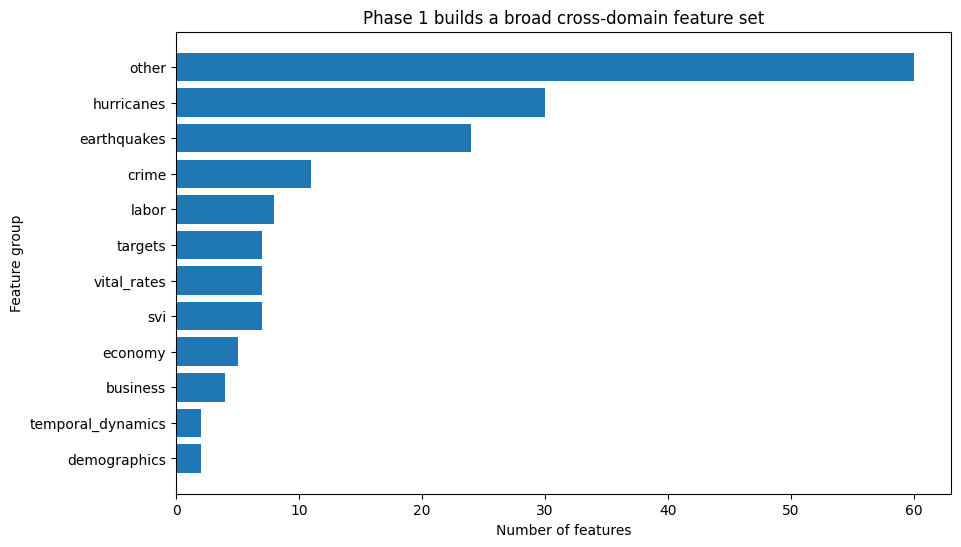

Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/feature_group_average_coverage.png


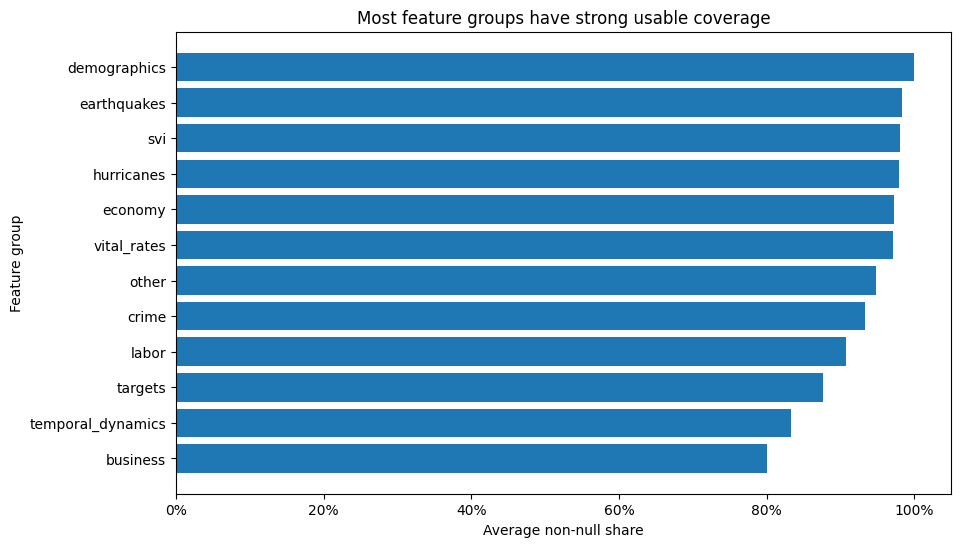

Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/target_pop_change_3y_avg_distribution.png


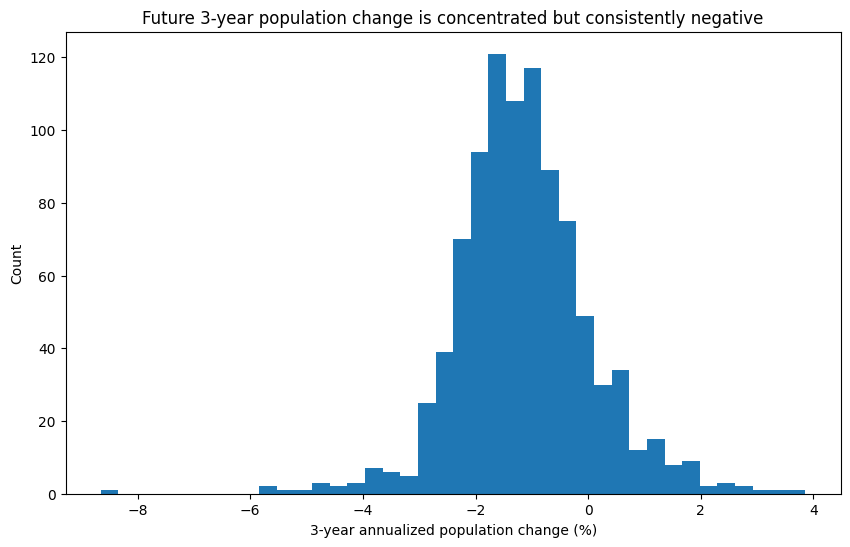

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/phase1_yearly_target_summary.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/yearly_target_trends.png


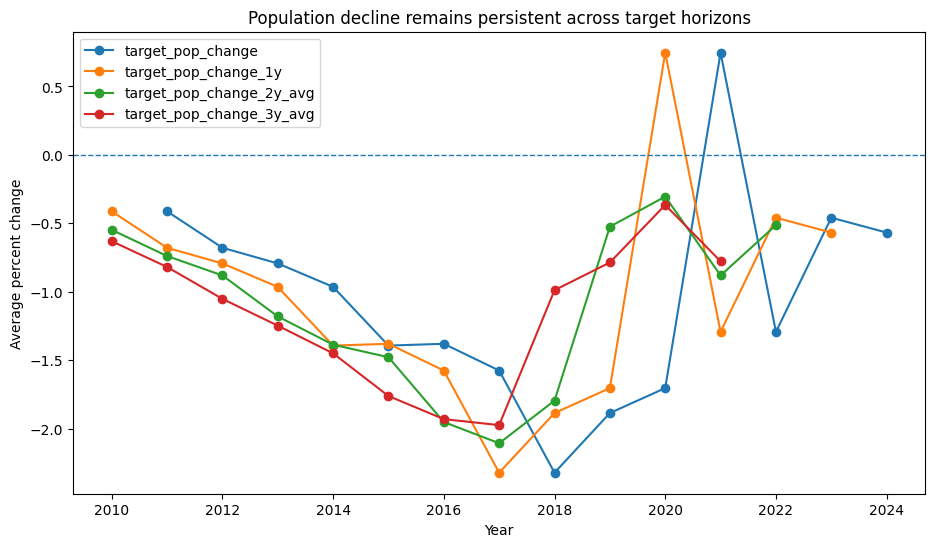

Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/svi_composite_vs_pca.png


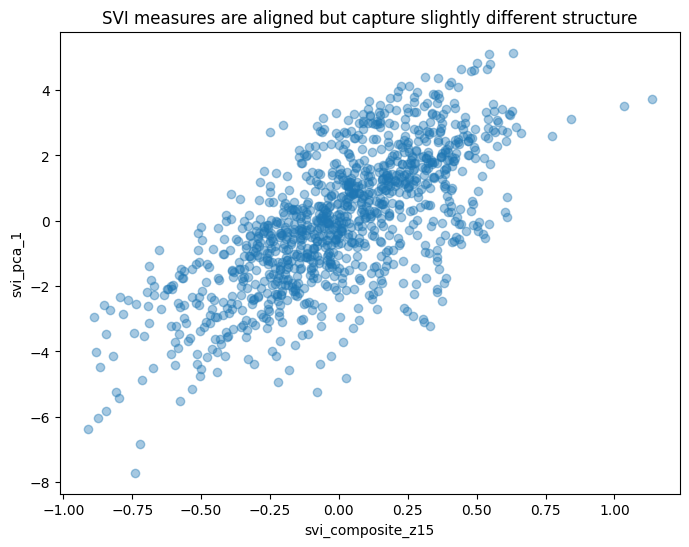

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/top20_baseline_vulnerability_municipalities.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/top20_baseline_vulnerability_municipalities.png


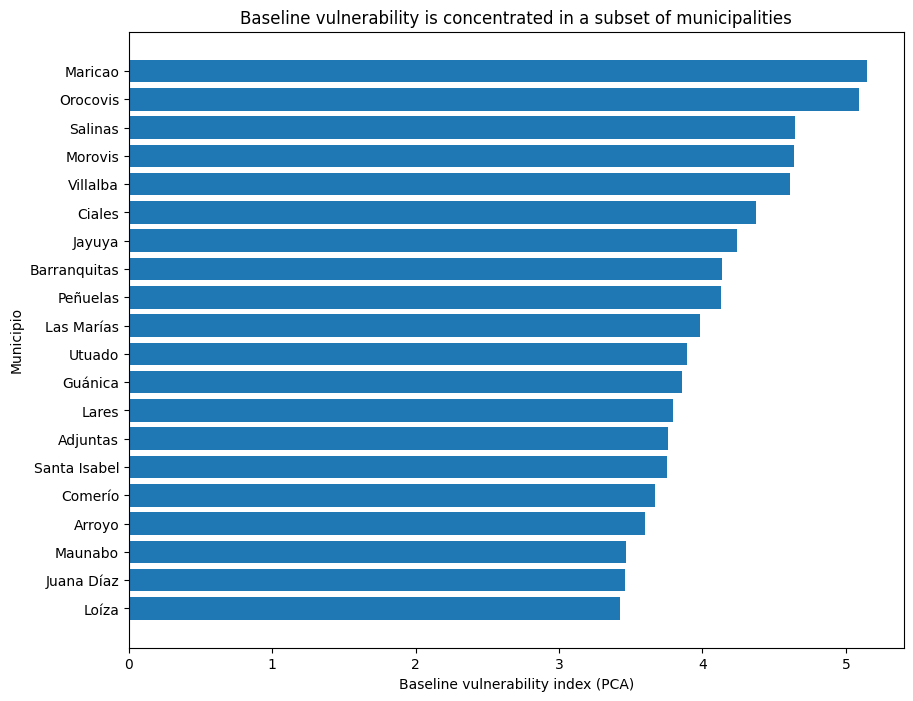

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/phase1_yearly_hazard_summary.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/yearly_rolling_hazard_exposure.png


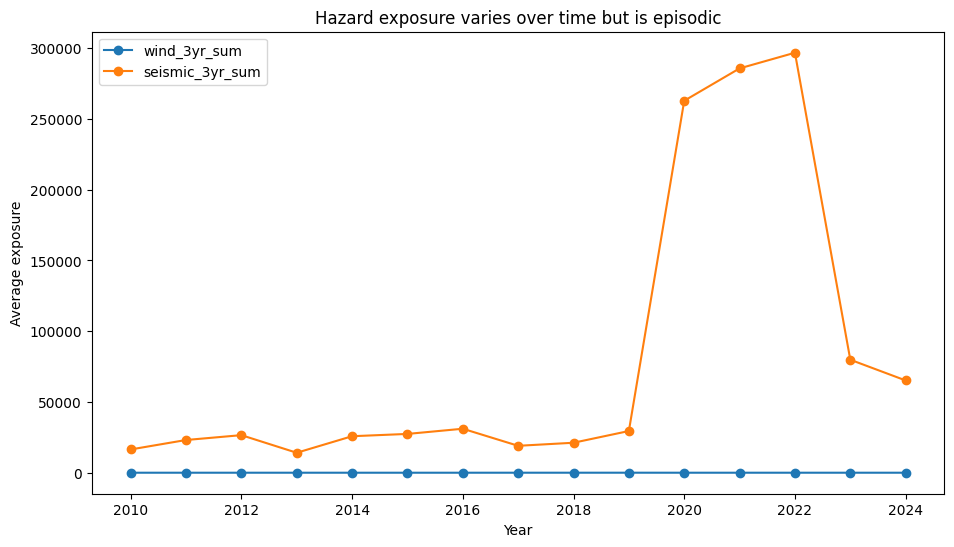

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/phase1_yearly_economic_summary.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/yearly_economic_momentum_features.png


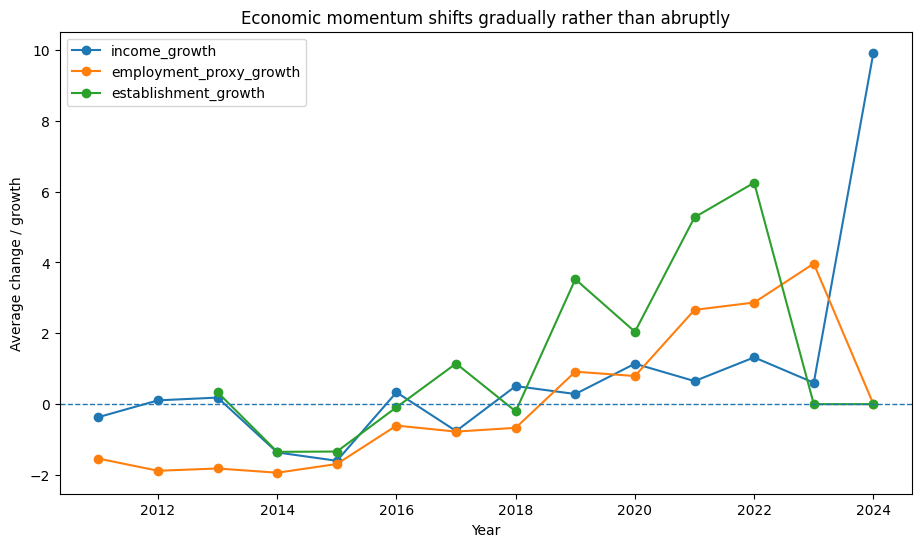

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/phase1_core_feature_correlations.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/core_feature_correlation_heatmap.png


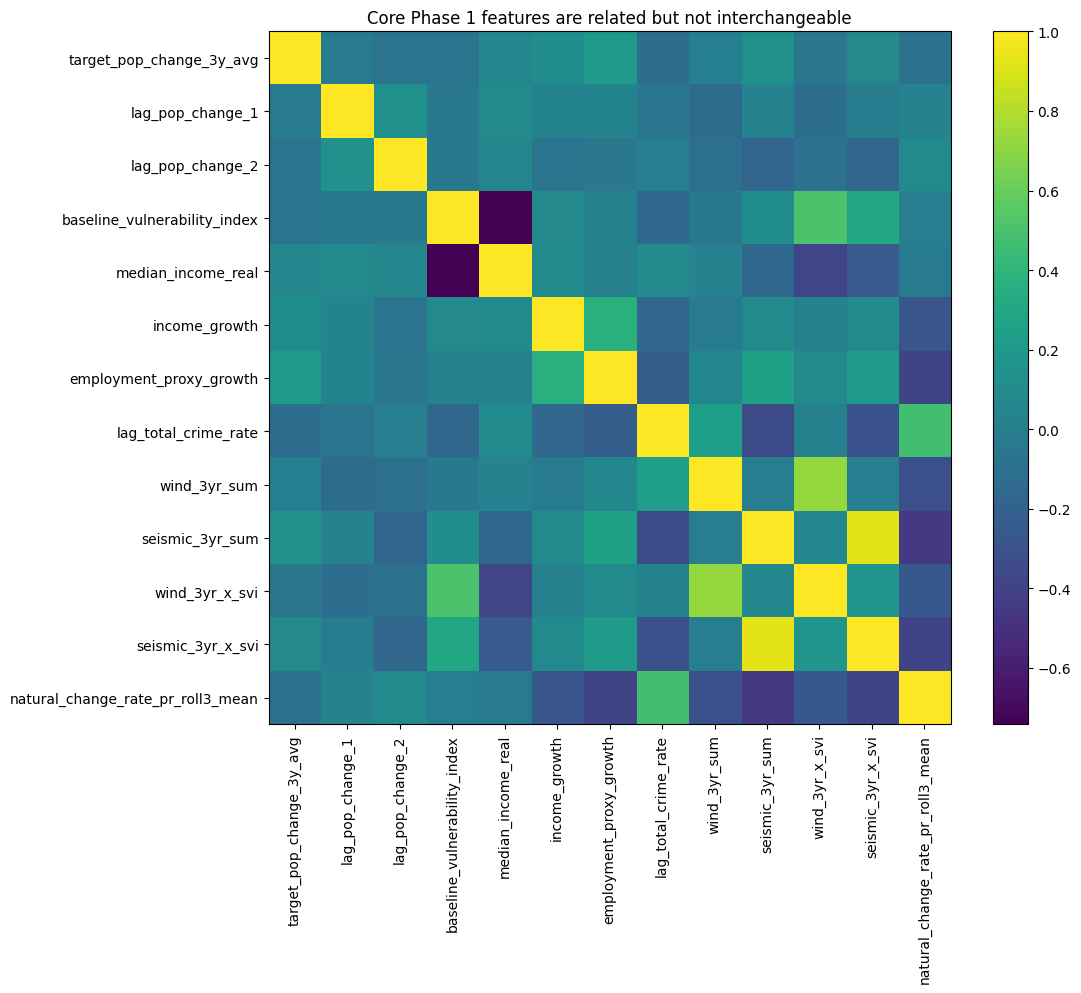

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/top25_correlations_with_target_pop_change_3y_avg.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/metadata/phase1_visual_summary.json


PosixPath('/Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/metadata/phase1_visual_summary.json')

In [6]:

# ---------------------------------
# Feature documentation and quality checks
# ---------------------------------
feature_group_map = {
    "total_population": "demographics",
    "total_population_16plus": "demographics",
    "target_pop_change": "targets",
    "target_pop_change_1y": "targets",
    "target_pop_change_2y_avg": "targets",
    "target_pop_change_3y_avg": "targets",
    "target_pop_change_1y_winsor_1_99": "targets",
    "target_pop_change_2y_avg_winsor_1_99": "targets",
    "target_pop_change_3y_avg_winsor_1_99": "targets",
    "lag_pop_change_1": "temporal_dynamics",
    "lag_pop_change_2": "temporal_dynamics",
    "baseline_vulnerability_index": "svi",
    "baseline_vulnerability_index_current": "svi",
    "baseline_svi_pca_1": "svi",
    "baseline_svi_composite_z15": "svi",
    "svi_pca_1": "svi",
    "svi_composite_z15": "svi",
    "high_svi_q75": "svi",
    "median_income_real": "economy",
    "median_income_nominal": "economy",
    "per_capita_income": "economy",
    "income_growth": "economy",
    "income_growth_3yr_avg": "economy",
    "unemployment_rate_pct": "labor",
    "emp_pop_ratio_pct": "labor",
    "labor_force_participation_pct": "labor",
    "employment_proxy_count": "labor",
    "employment_proxy_growth": "labor",
    "employment_ratio_change": "labor",
    "unemployment_rate_change": "labor",
    "labor_force_participation_change": "labor",
    "establishments_total_all_sectors": "business",
    "establishment_count": "business",
    "establishment_growth": "business",
    "lag_establishment_growth": "business",
    "murder_rate": "crime",
    "robbery_rate": "crime",
    "burglary_rate": "crime",
    "violent_crime_rate": "crime",
    "property_crime_rate": "crime",
    "total_crime_rate": "crime",
    "violent_crime_change": "crime",
    "property_crime_change": "crime",
    "lag_violent_crime_change": "crime",
    "lag_property_crime_change": "crime",
    "lag_total_crime_rate": "crime",
    "max_wind_knots": "hurricanes",
    "storm_count_100km": "hurricanes",
    "storm_count_200km": "hurricanes",
    "wind_exposure_score_100km": "hurricanes",
    "wind_exposure_score_200km": "hurricanes",
    "ts_windfield_hit": "hurricanes",
    "hurricane_windfield_hit": "hurricanes",
    "major_hurricane_count_200km": "hurricanes",
    "pr_annual_storm_count": "hurricanes",
    "pr_annual_max_wind": "hurricanes",
    "lag_max_wind_knots": "hurricanes",
    "lag_storm_count_100km": "hurricanes",
    "lag_storm_count_200km": "hurricanes",
    "lag_wind_exposure_score_100km": "hurricanes",
    "lag_wind_exposure_score_200km": "hurricanes",
    "lag_hurricane_windfield_hit": "hurricanes",
    "lag_pr_annual_storm_count": "hurricanes",
    "lag_pr_annual_max_wind": "hurricanes",
    "hurricane_event": "hurricanes",
    "hurricane_event_lag1": "hurricanes",
    "wind_3yr_sum": "hurricanes",
    "hurricane_x_svi": "hurricanes",
    "hurricane_x_svi_current": "hurricanes",
    "wind_3yr_x_svi": "hurricanes",
    "wind_3yr_x_svi_current": "hurricanes",
    "post_maria": "hurricanes",
    "maria_window_2017_2019": "hurricanes",
    "post_maria_x_high_svi": "hurricanes",
    "years_since_hurricane": "hurricanes",
    "years_since_hurricane_capped_5": "hurricanes",
    "max_seismic_mag": "earthquakes",
    "quake_count_50km": "earthquakes",
    "quake_count_100km": "earthquakes",
    "quake_count_mag35_100km": "earthquakes",
    "seismic_exposure_score_50km": "earthquakes",
    "seismic_exposure_score_100km": "earthquakes",
    "min_quake_distance_km": "earthquakes",
    "lag_max_seismic_mag": "earthquakes",
    "lag_quake_count_50km": "earthquakes",
    "lag_quake_count_100km": "earthquakes",
    "lag_seismic_exposure_score_50km": "earthquakes",
    "lag_seismic_exposure_score_100km": "earthquakes",
    "earthquake_event": "earthquakes",
    "earthquake_event_lag1": "earthquakes",
    "seismic_3yr_sum": "earthquakes",
    "earthquake_x_svi": "earthquakes",
    "earthquake_x_svi_current": "earthquakes",
    "seismic_3yr_x_svi": "earthquakes",
    "seismic_3yr_x_svi_current": "earthquakes",
    "post_earthquake_2020": "earthquakes",
    "quake_window_2020_2022": "earthquakes",
    "post_quake2020_x_high_svi": "earthquakes",
    "years_since_earthquake": "earthquakes",
    "years_since_earthquake_capped_5": "earthquakes",
    "birth_rate_pr": "vital_rates",
    "death_rate_pr": "vital_rates",
    "natural_change_rate_pr": "vital_rates",
    "birth_rate_pr_lag1": "vital_rates",
    "death_rate_pr_lag1": "vital_rates",
    "natural_change_rate_pr_lag1": "vital_rates",
    "natural_change_rate_pr_roll3_mean": "vital_rates"
}

feature_description_map = {
    "target_pop_change": "Observed year-over-year population percent change within municipality.",
    "target_pop_change_1y": "Forward one-year population percent change.",
    "target_pop_change_2y_avg": "Forward two-year annualized average population percent change.",
    "target_pop_change_3y_avg": "Forward three-year annualized average population percent change.",
    "lag_pop_change_1": "Previous year's municipal population change.",
    "lag_pop_change_2": "Two-year lag of municipal population change.",
    "svi_composite_z15": "Additive standardized social vulnerability composite using 15 indicators.",
    "svi_pca_1": "First PCA component from the 15-indicator SVI system.",
    "baseline_vulnerability_index": "Municipality baseline vulnerability anchored to first observed PCA-based SVI.",
    "baseline_vulnerability_index_current": "Municipality baseline vulnerability anchored to first observed additive SVI.",
    "wind_3yr_sum": "Three-year rolling sum of hurricane wind exposure.",
    "seismic_3yr_sum": "Three-year rolling sum of earthquake exposure.",
    "wind_3yr_x_svi": "Interaction between rolling hurricane exposure and baseline vulnerability.",
    "seismic_3yr_x_svi": "Interaction between rolling earthquake exposure and baseline vulnerability.",
    "income_growth": "Municipality median-income growth rate.",
    "employment_proxy_growth": "Growth in estimated employment count based on population 16+ and employment-population ratio.",
    "establishment_growth": "Growth in business establishment counts across all sectors.",
    "lag_total_crime_rate": "Lagged total crime rate per 100,000 residents.",
    "natural_change_rate_pr": "Islandwide birth minus death rate repeated as annual context across municipalities.",
    "natural_change_rate_pr_roll3_mean": "Three-year smoothed islandwide natural change rate."
}

def classify_transformation(col):
    if col.startswith("target_"):
        return "target"
    if col.startswith("lag_"):
        return "lag"
    if "_roll" in col or "_3yr_" in col:
        return "rolling"
    if "_x_" in col:
        return "interaction"
    if col.startswith("baseline_"):
        return "baseline"
    if col.endswith("_change") or col.endswith("_growth"):
        return "change_or_growth"
    return "raw_or_context"

feature_dictionary = pd.DataFrame({
    "feature_name": df.columns
})
feature_dictionary["feature_group"] = feature_dictionary["feature_name"].map(feature_group_map).fillna("other")
feature_dictionary["transformation"] = feature_dictionary["feature_name"].apply(classify_transformation)
feature_dictionary["non_null_count"] = feature_dictionary["feature_name"].map(df.notna().sum().to_dict())
feature_dictionary["non_null_share"] = feature_dictionary["non_null_count"] / len(df)
feature_dictionary["dtype"] = feature_dictionary["feature_name"].map(df.dtypes.astype(str).to_dict())
feature_dictionary["description"] = feature_dictionary["feature_name"].map(feature_description_map).fillna("Engineered or source variable used in the municipal panel.")
feature_dictionary = feature_dictionary.sort_values(["feature_group", "feature_name"]).reset_index(drop=True)

save_csv(feature_dictionary, "phase1_feature_dictionary.csv", index=False, folder=TABLE_DIR)

missingness_summary = (
    pd.DataFrame({
        "feature_name": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_share": (df.isna().sum() / len(df)).values,
        "non_null_count": df.notna().sum().values
    })
    .sort_values(["missing_share", "feature_name"], ascending=[False, True])
    .reset_index(drop=True)
)
save_csv(missingness_summary, "phase1_missingness_summary.csv", index=False, folder=TABLE_DIR)

feature_group_summary = (
    feature_dictionary.groupby("feature_group")
    .agg(
        n_features=("feature_name", "count"),
        avg_non_null_share=("non_null_share", "mean")
    )
    .reset_index()
    .sort_values(["n_features", "avg_non_null_share"], ascending=[False, False])
)
save_csv(feature_group_summary, "phase1_feature_group_summary.csv", index=False, folder=TABLE_DIR)

data_coverage_summary = pd.DataFrame([
    {"source_block": "master_panel", "non_null_rows": int(len(df))},
    {"source_block": "crime_total", "non_null_rows": int(df["total"].notna().sum()) if "total" in df.columns else 0},
    {"source_block": "income", "non_null_rows": int(df["median_income_real"].notna().sum()) if "median_income_real" in df.columns else 0},
    {"source_block": "employment", "non_null_rows": int(df["emp_pop_ratio_pct"].notna().sum()) if "emp_pop_ratio_pct" in df.columns else 0},
    {"source_block": "business_establishments", "non_null_rows": int(df["establishments_total_all_sectors"].notna().sum()) if "establishments_total_all_sectors" in df.columns else 0},
    {"source_block": "vital_rates", "non_null_rows": int(df["natural_change_rate_pr"].notna().sum()) if "natural_change_rate_pr" in df.columns else 0},
    {"source_block": "hurricane_features", "non_null_rows": int(df["wind_exposure_score_200km"].notna().sum()) if "wind_exposure_score_200km" in df.columns else 0},
    {"source_block": "earthquake_features", "non_null_rows": int(df["seismic_exposure_score_100km"].notna().sum()) if "seismic_exposure_score_100km" in df.columns else 0},
])
data_coverage_summary["share_of_rows"] = data_coverage_summary["non_null_rows"] / len(df)
save_csv(data_coverage_summary, "phase1_source_coverage_summary.csv", index=False, folder=TABLE_DIR)

# ---------------------------------
# Graphs for features and data quality
# ---------------------------------

# 1) Feature-group coverage
fg_plot = feature_group_summary.sort_values("n_features", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fg_plot["feature_group"], fg_plot["n_features"])
ax.set_title("Phase 1 builds a broad cross-domain feature set")
ax.set_xlabel("Number of features")
ax.set_ylabel("Feature group")
save_plot(fig, "feature_inventory_by_group.png")
plt.show()

# 2) Average data coverage by feature group
fg_cov = feature_group_summary.sort_values("avg_non_null_share", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fg_cov["feature_group"], fg_cov["avg_non_null_share"])
ax.set_title("Most feature groups have strong usable coverage")
ax.set_xlabel("Average non-null share")
ax.set_ylabel("Feature group")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.0%}"))
save_plot(fig, "feature_group_average_coverage.png")
plt.show()

# 3) Detailed top-missingness chart removed to avoid redundancy with the later missingness heatmap.

# 4) Main target distribution
main_target = df["target_pop_change_3y_avg"].dropna()
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(main_target, bins=40)
ax.set_title("Future 3-year population change is concentrated but consistently negative")
ax.set_xlabel("3-year annualized population change (%)")
ax.set_ylabel("Count")
save_plot(fig, "target_pop_change_3y_avg_distribution.png")
plt.show()

# 5) Yearly target trend (islandwide municipal average)
yearly_target = (
    df.groupby("year")[["target_pop_change", "target_pop_change_1y", "target_pop_change_2y_avg", "target_pop_change_3y_avg"]]
      .mean(numeric_only=True)
      .reset_index()
)
save_csv(yearly_target, "phase1_yearly_target_summary.csv", index=False, folder=TABLE_DIR)

fig, ax = plt.subplots(figsize=(11, 6))
for col in ["target_pop_change", "target_pop_change_1y", "target_pop_change_2y_avg", "target_pop_change_3y_avg"]:
    if col in yearly_target.columns:
        ax.plot(yearly_target["year"], yearly_target[col], marker="o", label=col)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Population decline remains persistent across target horizons")
ax.set_xlabel("Year")
ax.set_ylabel("Average percent change")
ax.legend()
save_plot(fig, "yearly_target_trends.png")
plt.show()

# 6) SVI measure comparison
svi_compare = df[["svi_composite_z15", "svi_pca_1"]].dropna()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(svi_compare["svi_composite_z15"], svi_compare["svi_pca_1"], alpha=0.4)
ax.set_title("SVI measures are aligned but capture slightly different structure")
ax.set_xlabel("svi_composite_z15")
ax.set_ylabel("svi_pca_1")
save_plot(fig, "svi_composite_vs_pca.png")
plt.show()

# 7) Baseline vulnerability by municipality
baseline_svi_rank = (
    df[["municipio", "baseline_vulnerability_index"]]
    .dropna()
    .drop_duplicates()
    .sort_values("baseline_vulnerability_index", ascending=False)
    .head(20)
    .sort_values("baseline_vulnerability_index", ascending=True)
)
save_csv(baseline_svi_rank.sort_values("baseline_vulnerability_index", ascending=False), "top20_baseline_vulnerability_municipalities.csv", index=False, folder=TABLE_DIR)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(baseline_svi_rank["municipio"], baseline_svi_rank["baseline_vulnerability_index"])
ax.set_title("Baseline vulnerability is concentrated in a subset of municipalities")
ax.set_xlabel("Baseline vulnerability index (PCA)")
ax.set_ylabel("Municipio")
save_plot(fig, "top20_baseline_vulnerability_municipalities.png")
plt.show()

# 8) Disaster feature trends
hazard_yearly = (
    df.groupby("year")[["wind_3yr_sum", "seismic_3yr_sum", "hurricane_event", "earthquake_event"]]
      .mean(numeric_only=True)
      .reset_index()
)
save_csv(hazard_yearly, "phase1_yearly_hazard_summary.csv", index=False, folder=TABLE_DIR)

fig, ax = plt.subplots(figsize=(11, 6))
for col in ["wind_3yr_sum", "seismic_3yr_sum"]:
    if col in hazard_yearly.columns:
        ax.plot(hazard_yearly["year"], hazard_yearly[col], marker="o", label=col)
ax.set_title("Hazard exposure varies over time but is episodic")
ax.set_xlabel("Year")
ax.set_ylabel("Average exposure")
ax.legend()
save_plot(fig, "yearly_rolling_hazard_exposure.png")
plt.show()

# 9) Economic feature trends
econ_yearly = (
    df.groupby("year")[["median_income_real", "income_growth", "employment_proxy_growth", "establishment_growth"]]
      .mean(numeric_only=True)
      .reset_index()
)
save_csv(econ_yearly, "phase1_yearly_economic_summary.csv", index=False, folder=TABLE_DIR)

fig, ax = plt.subplots(figsize=(11, 6))
for col in ["income_growth", "employment_proxy_growth", "establishment_growth"]:
    if col in econ_yearly.columns:
        ax.plot(econ_yearly["year"], econ_yearly[col], marker="o", label=col)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Economic momentum shifts gradually rather than abruptly")
ax.set_xlabel("Year")
ax.set_ylabel("Average change / growth")
ax.legend()
save_plot(fig, "yearly_economic_momentum_features.png")
plt.show()

# 10) Core feature relationship heatmap using correlations
feature_heatmap_cols = [
    "target_pop_change_3y_avg",
    "lag_pop_change_1",
    "lag_pop_change_2",
    "baseline_vulnerability_index",
    "median_income_real",
    "income_growth",
    "employment_proxy_growth",
    "lag_total_crime_rate",
    "wind_3yr_sum",
    "seismic_3yr_sum",
    "wind_3yr_x_svi",
    "seismic_3yr_x_svi",
    "natural_change_rate_pr_roll3_mean"
]
feature_heatmap_cols = [c for c in feature_heatmap_cols if c in df.columns]
corr_df = df[feature_heatmap_cols].corr(numeric_only=True)
save_csv(corr_df.reset_index(), "phase1_core_feature_correlations.csv", index=False, folder=TABLE_DIR)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_df.values, aspect="auto")
ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=90)
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index)
ax.set_title("Core Phase 1 features are related but not interchangeable")
fig.colorbar(im, ax=ax)
save_plot(fig, "core_feature_correlation_heatmap.png")
plt.show()

# 11) Correlation with the main target
if "target_pop_change_3y_avg" in df.columns:
    corr_target = (
        df.select_dtypes(include=[np.number])
          .corr(numeric_only=True)["target_pop_change_3y_avg"]
          .drop(labels=["target_pop_change_3y_avg"], errors="ignore")
          .dropna()
          .sort_values(key=lambda s: s.abs(), ascending=False)
          .head(25)
          .reset_index()
          .rename(columns={"index": "feature_name", "target_pop_change_3y_avg": "correlation_with_target"})
    )
    save_csv(corr_target, "top25_correlations_with_target_pop_change_3y_avg.csv", index=False, folder=TABLE_DIR)

# Bar plot removed to avoid redundancy with the later slide-ready top-features figure.

phase1_visual_summary = {
    "phase1_root": str(PHASE1_DIR),
    "figures_dir": str(FIG_DIR),
    "tables_dir": str(TABLE_DIR),
    "data_dir": str(DATA_DIR),
    "metadata_dir": str(META_DIR),
    "n_saved_figures": len(list(FIG_DIR.glob("*.png"))),
    "n_saved_tables": len(list(TABLE_DIR.glob("*.csv"))),
}
save_json(phase1_visual_summary, "phase1_visual_summary.json", folder=META_DIR)


## 6. Feature signal summary and explanatory diagnostics

This section upgrades Phase 1 from **feature construction** to **feature interpretation**.

It focuses on six questions that directly motivate Phase 2:

1. Do lagged population-change features dominate the signal?
2. Do disaster features show weak direct relationships with the target?
3. Which feature groups look strongest before modeling?
4. How does the target evolve across regions over time?
5. What is the overall structure of missingness and core feature correlation?
6. Which single set of features best summarizes the Phase 1 story for slides?

**Interpretive expectation:** if lagged population dynamics are much stronger than disaster features, then the later predictive models will likely depend more on persistence and temporal structure than on direct event-year shocks.


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/lag_population_change_vs_target_correlations.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/lag_population_change_vs_target.png


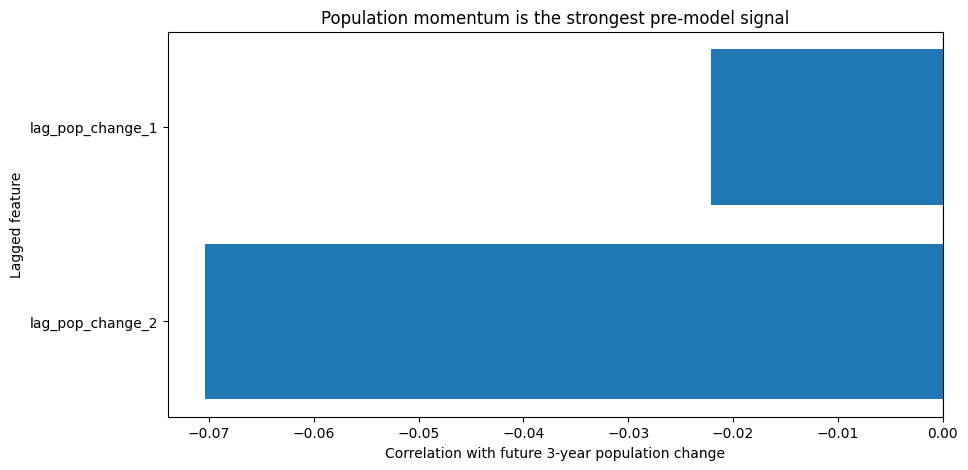

Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/wind_3yr_sum_vs_target_pop_change_3y_avg.png


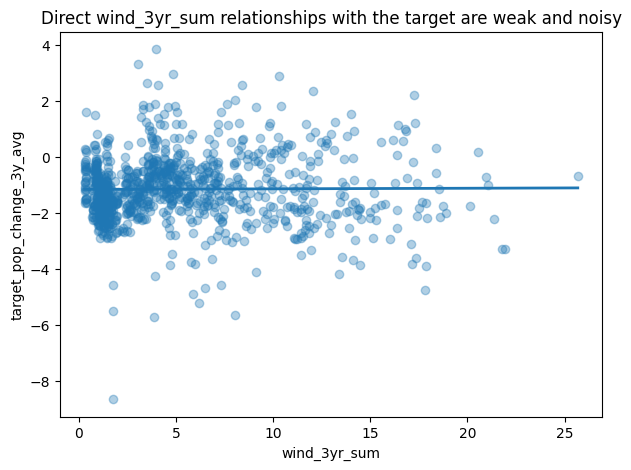

Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/seismic_3yr_sum_vs_target_pop_change_3y_avg.png


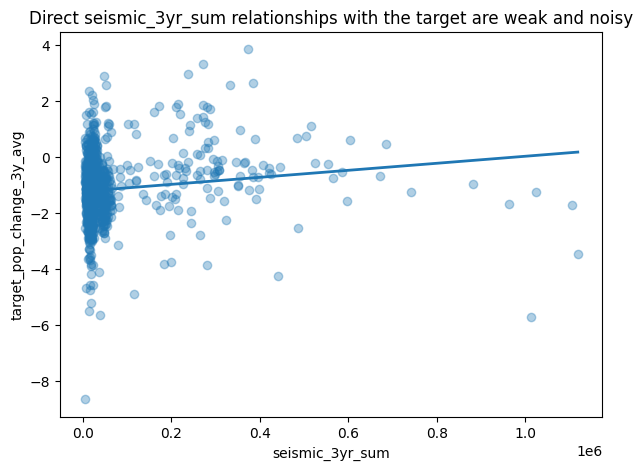

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/hazard_features_vs_target_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/feature_group_importance_proxy.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/feature_group_importance_proxy.png


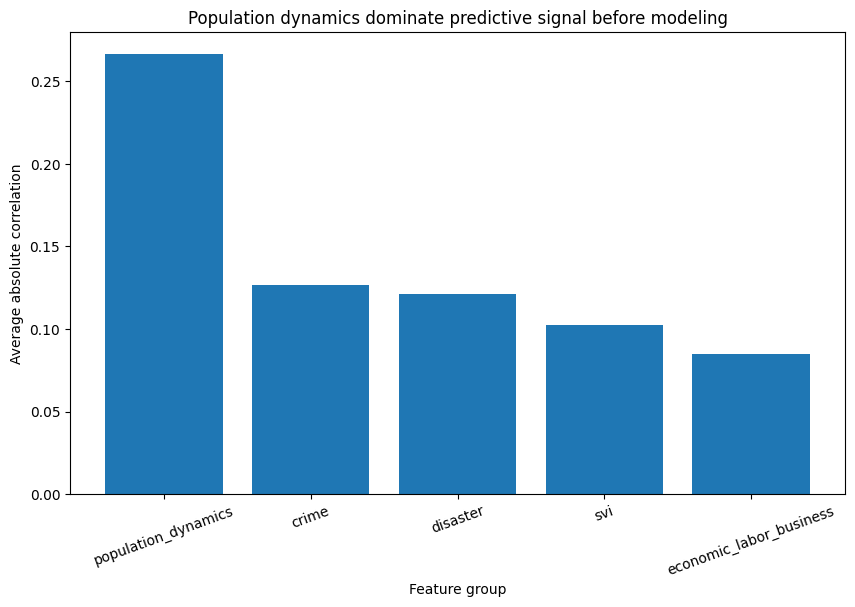

Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/missingness_heatmap_top25_features.png


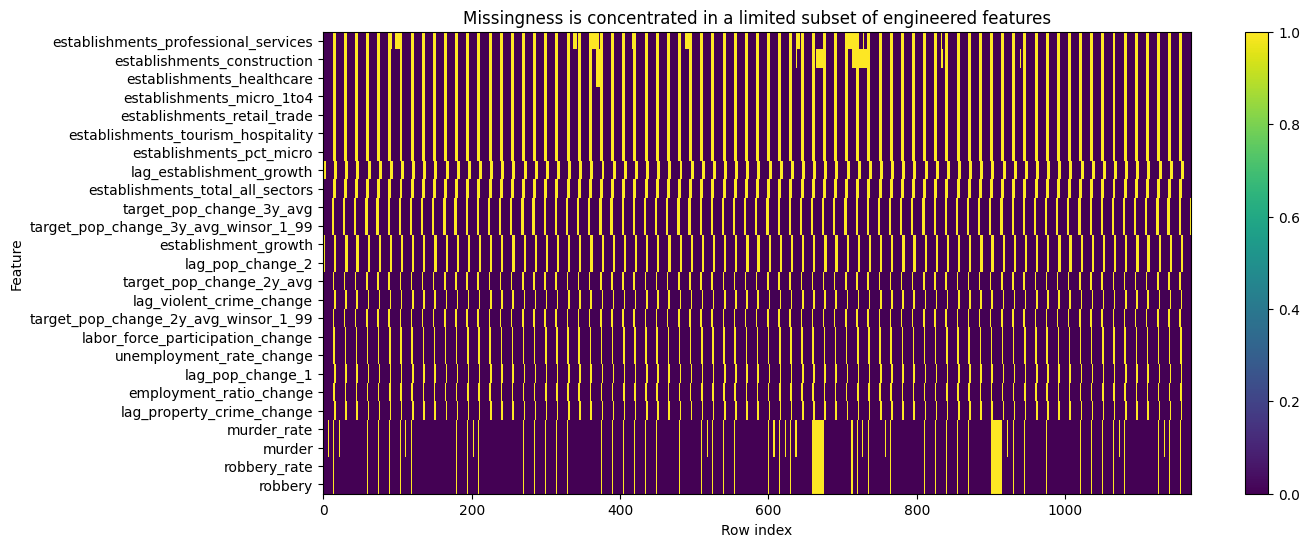

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/top_feature_correlation_heatmap_values.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/top15_feature_correlation_heatmap.png


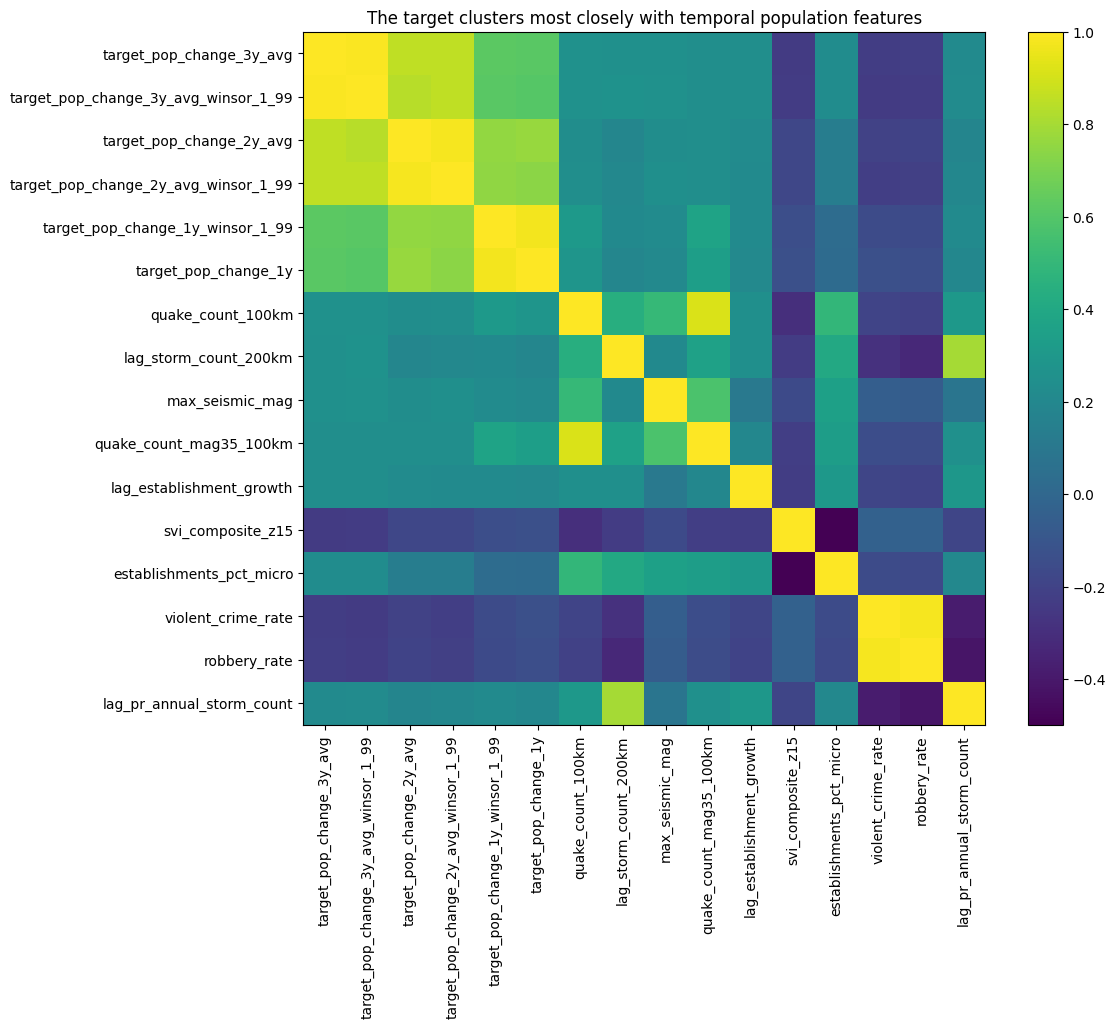

Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/top15_features_vs_target_pop_change_3y_avg.csv
Saved figure: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/figures/top15_features_vs_target_pop_change_3y_avg.png


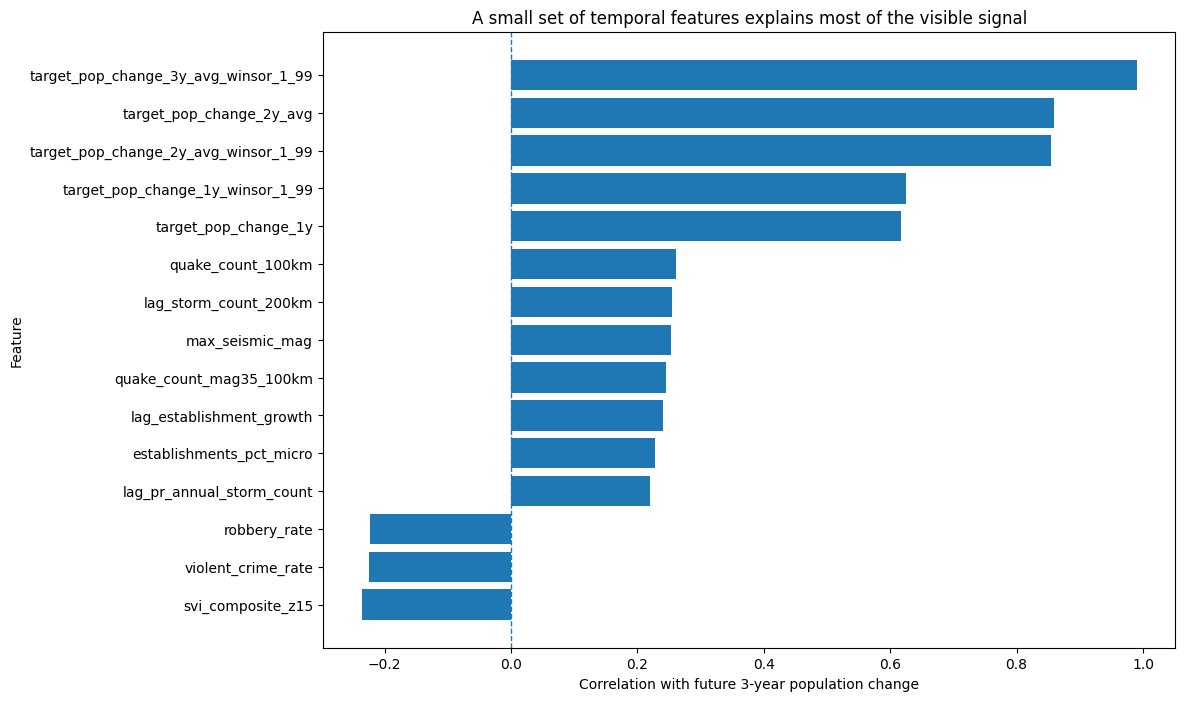

Phase 1 feature signal summary
- Lagged population-change features show the strongest direct signal; the top lag correlation is 0.070 for lag_pop_change_2.
- Direct disaster-feature relationships with the target are weaker; the strongest hazard correlation is 0.134 for seismic_3yr_sum.
- Before modeling, the feature group with the strongest average target relationship is population_dynamics (average absolute correlation 0.267).
- Phase 1 therefore suggests that Puerto Rico population change is highly path-dependent: lagged population structure carries the clearest signal, disasters appear weak as direct stand-alone predictors, and economic or vulnerability variables act mainly as secondary modifiers.


In [7]:

# ---------------------------------
# Explanatory diagnostics for Phase 2 motivation
# ---------------------------------

target_col = "target_pop_change_3y_avg"

# helper for safe numeric selection
def existing_cols(cols):
    return [c for c in cols if c in df.columns]

# 1) Lag dominance plot
lag_features = [
    c for c in df.columns
    if ("lag" in c.lower()) and ("pop_change" in c.lower())
]
lag_features = [c for c in lag_features if c != target_col]

if target_col in df.columns and lag_features:
    lag_corr = (
        df[lag_features + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(labels=[target_col], errors="ignore")
        .dropna()
        .sort_values()
    )
    lag_corr_df = lag_corr.reset_index()
    lag_corr_df.columns = ["feature_name", "correlation_with_target"]
    save_csv(lag_corr_df, "lag_population_change_vs_target_correlations.csv", index=False, folder=TABLE_DIR)

    fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(lag_corr_df))))
    ax.barh(lag_corr_df["feature_name"], lag_corr_df["correlation_with_target"])
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title("Population momentum is the strongest pre-model signal")
    ax.set_xlabel("Correlation with future 3-year population change")
    ax.set_ylabel("Lagged feature")
    save_plot(fig, "lag_population_change_vs_target.png")
    plt.show()

# 2) Disaster vs target scatterplots
hazard_features = [c for c in ["wind_3yr_sum", "seismic_3yr_sum"] if c in df.columns]
hazard_vs_target_rows = []

for feat in hazard_features:
    tmp = df[[feat, target_col]].dropna()
    if len(tmp) > 1:
        corr_val = tmp[feat].corr(tmp[target_col])
        hazard_vs_target_rows.append({
            "feature_name": feat,
            "n_obs": int(len(tmp)),
            "correlation_with_target": float(corr_val) if pd.notna(corr_val) else np.nan
        })

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(tmp[feat], tmp[target_col], alpha=0.35)
        if tmp[feat].nunique() > 1:
            z = np.polyfit(tmp[feat], tmp[target_col], 1)
            xline = np.linspace(tmp[feat].min(), tmp[feat].max(), 100)
            ax.plot(xline, z[0] * xline + z[1], linewidth=2)
        ax.set_title(f"Direct {feat} relationships with the target are weak and noisy")
        ax.set_xlabel(feat)
        ax.set_ylabel(target_col)
        save_plot(fig, f"{feat}_vs_{target_col}.png")
        plt.show()

if hazard_vs_target_rows:
    save_csv(pd.DataFrame(hazard_vs_target_rows), "hazard_features_vs_target_summary.csv", index=False, folder=TABLE_DIR)

# 3) Feature-group importance proxy using average absolute correlation with target
feature_groups_for_signal = {
    "population_dynamics": [c for c in df.columns if ("pop" in c.lower()) or ("natural_change" in c.lower())],
    "disaster": [c for c in df.columns if any(k in c.lower() for k in ["wind", "storm", "hurricane", "seismic", "quake", "earthquake"])],
    "svi": [c for c in df.columns if "svi" in c.lower() or "vulnerability" in c.lower()],
    "economic_labor_business": [c for c in df.columns if any(k in c.lower() for k in ["income", "employment", "unemployment", "labor", "establishment"])],
    "crime": [c for c in df.columns if "crime" in c.lower() or c.lower() in {"murder_rate", "robbery_rate", "burglary_rate"}],
}

group_signal_rows = []
if target_col in df.columns:
    for group_name, cols in feature_groups_for_signal.items():
        cols = [c for c in cols if c in df.columns and c != target_col]
        numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
        if numeric_cols:
            corr_vals = (
                df[numeric_cols + [target_col]]
                .corr(numeric_only=True)[target_col]
                .drop(labels=[target_col], errors="ignore")
                .dropna()
            )
            if len(corr_vals) > 0:
                group_signal_rows.append({
                    "feature_group": group_name,
                    "n_features": int(len(corr_vals)),
                    "avg_abs_correlation_with_target": float(corr_vals.abs().mean()),
                    "max_abs_correlation_with_target": float(corr_vals.abs().max())
                })

if group_signal_rows:
    group_signal_df = pd.DataFrame(group_signal_rows).sort_values("avg_abs_correlation_with_target", ascending=False)
    save_csv(group_signal_df, "feature_group_importance_proxy.csv", index=False, folder=TABLE_DIR)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(group_signal_df["feature_group"], group_signal_df["avg_abs_correlation_with_target"])
    ax.set_title("Population dynamics dominate predictive signal before modeling")
    ax.set_xlabel("Feature group")
    ax.set_ylabel("Average absolute correlation")
    ax.tick_params(axis="x", rotation=20)
    save_plot(fig, "feature_group_importance_proxy.png")
    plt.show()

# 4) Population decline by region over time
if all(c in df.columns for c in ["year", "region", target_col]):
    region_yearly = (
        df.groupby(["year", "region"])[target_col]
        .mean()
        .reset_index()
    )
    save_csv(region_yearly, "region_yearly_target_pop_change_3y_avg.csv", index=False, folder=TABLE_DIR)

    pivot_region = region_yearly.pivot(index="year", columns="region", values=target_col).sort_index()
    if not pivot_region.empty:
        fig, ax = plt.subplots(figsize=(12, 7))
        for col in pivot_region.columns:
            ax.plot(pivot_region.index, pivot_region[col], marker="o", label=col)
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title("Regional decline is persistent, but not identical across Puerto Rico")
        ax.set_xlabel("Year")
        ax.set_ylabel("Average target_pop_change_3y_avg")
        ax.legend(loc="best", fontsize=8, ncols=2)
        save_plot(fig, "region_population_trends.png")
        plt.show()

# 5) Missingness heatmap for top-missing features
numeric_missing = (
    df.isna().mean()
    .sort_values(ascending=False)
)
top_missing_cols = numeric_missing.head(25).index.tolist()
if top_missing_cols:
    miss_mat = df[top_missing_cols].isna().astype(int).values

    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(miss_mat.T, aspect="auto", interpolation="nearest")
    ax.set_title("Missingness is concentrated in a limited subset of engineered features")
    ax.set_xlabel("Row index")
    ax.set_ylabel("Feature")
    ax.set_yticks(range(len(top_missing_cols)))
    ax.set_yticklabels(top_missing_cols)
    fig.colorbar(im, ax=ax)
    save_plot(fig, "missingness_heatmap_top25_features.png")
    plt.show()

# 6) Tighter top-feature correlation heatmap
if target_col in df.columns:
    top_corr_features = (
        df.select_dtypes(include=[np.number])
        .corr(numeric_only=True)[target_col]
        .drop(labels=[target_col], errors="ignore")
        .dropna()
        .abs()
        .sort_values(ascending=False)
        .head(15)
        .index
        .tolist()
    )
    heat_cols = existing_cols([target_col] + top_corr_features)
    if len(heat_cols) >= 3:
        corr_top = df[heat_cols].corr(numeric_only=True)
        save_csv(corr_top.reset_index(), "top_feature_correlation_heatmap_values.csv", index=False, folder=TABLE_DIR)

        fig, ax = plt.subplots(figsize=(11, 9))
        im = ax.imshow(corr_top.values, aspect="auto")
        ax.set_xticks(range(len(corr_top.columns)))
        ax.set_xticklabels(corr_top.columns, rotation=90)
        ax.set_yticks(range(len(corr_top.index)))
        ax.set_yticklabels(corr_top.index)
        ax.set_title("The target clusters most closely with temporal population features")
        fig.colorbar(im, ax=ax)
        save_plot(fig, "top15_feature_correlation_heatmap.png")
        plt.show()


# 7) Slide-ready top-features figure
if target_col in df.columns:
    top_features_df = (
        df.select_dtypes(include=[np.number])
        .corr(numeric_only=True)[target_col]
        .drop(labels=[target_col], errors="ignore")
        .dropna()
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .head(15)
        .reset_index()
    )
    top_features_df.columns = ["feature_name", "correlation_with_target"]
    save_csv(top_features_df, "top15_features_vs_target_pop_change_3y_avg.csv", index=False, folder=TABLE_DIR)

    plot_df = top_features_df.sort_values("correlation_with_target")
    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(plot_df["feature_name"], plot_df["correlation_with_target"])
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title("A small set of temporal features explains most of the visible signal")
    ax.set_xlabel("Correlation with future 3-year population change")
    ax.set_ylabel("Feature")
    save_plot(fig, "top15_features_vs_target_pop_change_3y_avg.png")
    plt.show()

# 8) Narrative summary export

signal_summary_lines = []

if target_col in df.columns and lag_features:
    lag_corr_abs = (
        df[lag_features + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(labels=[target_col], errors="ignore")
        .dropna()
        .abs()
        .sort_values(ascending=False)
    )
    if len(lag_corr_abs) > 0:
        signal_summary_lines.append(
            f"Lagged population-change features show the strongest direct signal; the top lag correlation is {lag_corr_abs.iloc[0]:.3f} for {lag_corr_abs.index[0]}."
        )

if hazard_vs_target_rows:
    hazard_df = pd.DataFrame(hazard_vs_target_rows).sort_values("correlation_with_target", key=lambda s: s.abs(), ascending=False)
    top_hazard = hazard_df.iloc[0]
    signal_summary_lines.append(
        f"Direct disaster-feature relationships with the target are weaker; the strongest hazard correlation is {top_hazard['correlation_with_target']:.3f} for {top_hazard['feature_name']}."
    )

if group_signal_rows:
    top_group = pd.DataFrame(group_signal_rows).sort_values("avg_abs_correlation_with_target", ascending=False).iloc[0]
    signal_summary_lines.append(
        f"Before modeling, the feature group with the strongest average target relationship is {top_group['feature_group']} (average absolute correlation {top_group['avg_abs_correlation_with_target']:.3f})."
    )

signal_summary_lines.append(
    "Phase 1 therefore suggests that Puerto Rico population change is highly path-dependent: lagged population structure carries the clearest signal, disasters appear weak as direct stand-alone predictors, and economic or vulnerability variables act mainly as secondary modifiers."
)

signal_summary_text = "\n".join(f"- {line}" for line in signal_summary_lines)

with open(META_DIR / "phase1_feature_signal_summary.md", "w", encoding="utf-8") as f:
    f.write("# Phase 1 Feature Signal Summary\n\n")
    f.write(signal_summary_text + "\n")

print("Phase 1 feature signal summary")
print(signal_summary_text)


## Interpretation of the key Phase 1 figures

### Population momentum is the strongest pre-model signal
**Interpretation:** Lagged population-change variables show the clearest relationship with future population change. This indicates that Puerto Rico’s demographic dynamics are strongly persistent: past decline or stabilization tends to carry forward into later years. This pattern provides the strongest **pre-model predictive signal** and directly motivates the emphasis on lagged features in Phase 2 modeling.

---

### Direct disaster-feature relationships are weak and noisy
**Interpretation:** The hurricane and earthquake scatterplots do not show a clean direct relationship with the target. This suggests that disasters are not acting as simple stand-alone predictors in the panel; instead, their effects are likely **indirect, delayed, or absorbed through longer-run demographic change**, consistent with a lag-driven modeling framework.

---

### Population dynamics dominate before modeling
**Interpretation:** When features are grouped into broad families, population-related variables carry the strongest average signal. Economic and vulnerability variables provide useful context, but they do not outweigh temporal population structure. This reinforces the importance of prioritizing lagged and rolling features in Phase 2.

---

### Regional decline is persistent but uneven
**Interpretation:** Population decline is not uniform across regions. This matters for Phase 2 because a single islandwide model must still capture meaningful cross-regional heterogeneity, motivating the inclusion of geographic and regional structure in the feature set.

---

### Missingness is concentrated rather than universal
**Interpretation:** Data quality issues are present, but they are concentrated in a smaller subset of engineered variables rather than spread evenly across the full panel. This makes the dataset suitable for modeling with targeted preprocessing rather than broad data exclusion.

---

### Slide-ready top-features figure
**Interpretation:** The strongest pre-model relationships are concentrated in a relatively small set of temporal and demographic variables. This provides a clear visual bridge into Phase 2, where model selection and interpretability confirm that these same features drive predictive performance.

## Phase 1 Key Insight

The data strongly indicate that Puerto Rico’s population dynamics are highly **path-dependent**.

Lagged population-change variables show the strongest and most consistent relationship with future population change, indicating that demographic momentum plays a dominant role in shaping outcomes over time.

In contrast, disaster exposure variables exhibit weak and noisy direct relationships with the target. This suggests that their effects are primarily **indirect and delayed**, operating through longer-term structural and migration responses that are captured by lagged population dynamics rather than immediate one-period shifts.

Economic and vulnerability features provide important contextual information, but they do not outweigh the influence of temporal population structure.

Taken together, these findings imply that effective predictive models should rely primarily on **lagged population dynamics and temporal features**, with other variables acting as secondary modifiers within that structure.

This insight directly informs the Phase 2 modeling strategy, where a regularized linear model leverages these lagged relationships to produce stable and interpretable out-of-sample predictions.

## 5. Export enriched panel and feature inventory

In [8]:

summary_overview = {
    "rows": int(len(df)),
    "municipalities": int(df["municipio"].nunique()),
    "years_min": int(df["year"].min()),
    "years_max": int(df["year"].max()),
    "svi_pca_explained_variance_ratio": float(svi_pca_explained_variance_ratio),
    "baseline_svi_q50": float(baseline_svi_q50) if pd.notna(baseline_svi_q50) else None,
    "baseline_svi_q75": float(baseline_svi_q75) if pd.notna(baseline_svi_q75) else None,
    "preferred_features_available": available_features,
    "preferred_features_missing": missing_features,
    "svi_indicator_columns": svi_pca_cols,
}
save_json(summary_overview, "phase1_rebuild_v5_overview.json", folder=META_DIR)

enriched_path = DATA_DIR / "processed_puerto_rico_data_enriched.csv"
rebuild_path = DATA_DIR / "processed_puerto_rico_data_rebuild.csv"

df.to_csv(enriched_path, index=False)
df.to_csv(rebuild_path, index=False)

print(f"Saved enriched master panel: {enriched_path}")
print(f"Saved rebuild-compatible panel: {rebuild_path}")

feature_inventory = pd.DataFrame({
    "column": df.columns,
    "non_null_count": df.notna().sum().values,
    "dtype": df.dtypes.astype(str).values
}).sort_values(["non_null_count", "column"], ascending=[False, True])

save_csv(feature_inventory, "feature_inventory.csv", index=False, folder=TABLE_DIR)

phase1_readme = """
Phase1 output structure
- data/: exported modeling datasets
- tables/: feature inventory, missingness, coverage, and summary tables
- figures/: Phase 1 diagnostic and feature-exploration graphs
- metadata/: overview JSON files and notebook metadata exports

Recommended Phase 2 input:
- Phase1/data/processed_puerto_rico_data_rebuild.csv
""".strip()
save_text(phase1_readme, "README.txt", folder=PHASE1_DIR)

print("\nPhase 1 rebuild v5 complete.")
print("Use 'Phase1/data/processed_puerto_rico_data_rebuild.csv' as the Phase 2 input.")
print("For vulnerability comparison in Phase 2, test both 'baseline_vulnerability_index' (PCA) and 'baseline_vulnerability_index_current' (additive z-score composite).")


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/metadata/phase1_rebuild_v5_overview.json
Saved enriched master panel: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/data/processed_puerto_rico_data_enriched.csv
Saved rebuild-compatible panel: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/data/processed_puerto_rico_data_rebuild.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/tables/feature_inventory.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/Phase1/README.txt

Phase 1 rebuild v5 complete.
Use 'Phase1/data/processed_puerto_rico_data_rebuild.csv' as the Phase 2 input.
For vulnerability comparison in Phase 2, test both 'baseline_vulnerability_index' (PCA) and 'baseline_vulnerability_index_current' (ad